# Western Balkan Studies

* load packages

In [1]:
import warnings
from pathlib import Path

import geopandas as gpd
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import RES.visuals as vis
from RES import utility as utils
from RES.hdf5_handler import DataHandler

plt.style.use('../RES/visual_styles/elsevier.mplstyle')
# Suppress specific warnings
warnings.filterwarnings("ignore", category=UserWarning)
cfg=utils.load_config('../config/config_WB6.yaml')
sub_national_unit_tag=cfg.get('GADM').get('datafield_mapping').get('NAME_2')

# Define Province Code

In [2]:
# Construct region_options as a list of tuples: (name, code)
region_options = [(cfg['region_mapping'][code]['name'], code) for code in cfg['region_mapping']]
region_code = 'BA'  # Default selection, change as needed

# Create dropdown widget for region codes with names shown, codes as values
region_code_dropdown = widgets.Dropdown(
    options=region_options,
    value=region_code,
    description='Region:',
    disabled=False,
)

display(region_code_dropdown)

Dropdown(description='Region:', index=1, options=(('Albania', 'AL'), ('Bosnia and Herzegovina', 'BA'), ('Kosov…

In [3]:
region_code = region_code_dropdown.value
region_name=cfg.get('region_mapping').get(region_code).get('name') # type: ignore
country_name=cfg.get('country','Western Balkan Region') # type: ignore
country_kwd=country_name.replace(' ','')
utils.print_banner(f"Selected Region: {region_name} ({region_code})")

********************************************
Selected Region: Bosnia and Herzegovina (BA)
********************************************


##  Define run/scenario

In [4]:
# Define the directory and search pattern
data_store_dir = Path("../data/store/")
search_keyword = f"resources_{country_kwd}_{region_code}_"

# List files containing the search pattern
matching_files = [str(f) for f in data_store_dir.glob(f"*{search_keyword}*") if f.is_file()]

# Extract run IDs from matching_files
run_ids = [f.replace(str(data_store_dir) + '/', '').replace(search_keyword, '').replace(".h5", '') for f in matching_files]



RUN_ID="default"

# Create dropdown widget
run_id_dropdown = widgets.Dropdown(
    options=run_ids,
    value=RUN_ID,
    description='Run ID:',
    disabled=False,
)

display(run_id_dropdown)

Dropdown(description='Run ID:', options=('default',), value='default')

## Load Store

In [5]:
RUN_ID= run_id_dropdown.value
store=f"../data/store/resources_{country_kwd}_{region_code}_{RUN_ID}.h5"# f"../data/store/resources_{province_code}.h5" 
res_data=DataHandler(store,show_structure=False) # the DataHandler object could be initiated without the store definition as well.

# Load Data from Store

In [6]:
# Loading Geodataframes
cells=res_data.from_store('cells')
boundary=res_data.from_store('boundary')
lines=res_data.from_store('lines')
# if lines is None:
#     lines=gpd.read_file('../data/downloaded_data/OSM/BC_power.geojson')
res_data.to_store(lines, 'lines')
substations=res_data.from_store('substations')
timeseries_solar=res_data.from_store('timeseries/solar')
timeseries_wind=res_data.from_store('timeseries/wind')
timeseries_clusters_solar=res_data.from_store('timeseries/clusters/solar')
timeseries_clusters_wind=res_data.from_store('timeseries/clusters/wind')
clusters_solar=res_data.from_store('clusters/solar')
clusters_wind=res_data.from_store('clusters/wind')

  └> RES.hdf5_handler| 💾 Updated 'lines' saved to ../data/store/resources_WesternBalkanRegions_BA_default.h5 with key 'lines'
  └> RES.hdf5_handler| ❌ Error: Key 'substations' not found in ../data/store/resources_WesternBalkanRegions_BA_default.h5


* load Validation data (whatever we have)

In [8]:
existing_VREs_data_path=Path(f"../data/validation_data/existing_VRE_WB6.csv")
if existing_VREs_data_path.exists():
    existing_VREs=pd.read_csv(existing_VREs_data_path)
    existing_VREs_gdf=gpd.GeoDataFrame(existing_VREs,geometry=gpd.points_from_xy(existing_VREs.lon,existing_VREs.lat),crs="EPSG:4326")
else:
    existing_VREs_gdf=None
    utils.print_warning(f"Validation data for existing VREs not found at {existing_VREs_data_path}")

⚠️  Validation data for existing VREs not found at ../data/validation_data/existing_VRE_WB6.csv



# CF checks

In [9]:
gwa_country_code=cfg.get('region_mapping').get(region_code).get('GWA_country_code')
utils.print_banner(f"GWA Country Code Selected: {gwa_country_code}")

******************************
GWA Country Code Selected: BIH
******************************


### Wind

In [10]:
# boundary.to_crs(epsg=3035,inplace=True)

# Get total bounds from boundary GeoDataFrame
minx, miny, maxx, maxy = boundary.total_bounds

# Create bounding_box_dict with correct keys for downstream use
bounding_box_dict = {
    "minx": float(minx),
    "miny": float(miny),
    "maxx": float(maxx),
    "maxy": float(maxy)
}


* Load Wind CF raster (Benchmark)

In [11]:
import rioxarray as rxr

raster_path=f'../data/downloaded_data/GWA/{gwa_country_code}_capacity-factor_IEC3.tif'
gwa_raster_data = (
        rxr.open_rasterio(raster_path)
        .rio.clip_box(**bounding_box_dict)
        .rename('CF_IEC3')
        .isel(band=1 if '*Class*' in 'CF_IEC3' else 0)  # 'IEC_Class_ExLoads' data is in band 1
        .drop_vars(['band', 'spatial_ref'])
    )


# Corine Land Cover

In [12]:
boundary_x=boundary.to_crs(epsg=3035)

# Get total bounds from boundary GeoDataFrame
minx, miny, maxx, maxy = boundary_x.total_bounds

# Create bounding_box_dict with correct keys for downstream use
bounding_box_dict = {
    "minx": float(minx),
    "miny": float(miny),
    "maxx": float(maxx),
    "maxy": float(maxy)
}


In [13]:
import rasterio

raster_path = '../data/downloaded_data/CORINE/U2018_CLC2018_V2020_20u1.tif'
CLC_raster_data = (
        rxr.open_rasterio(raster_path)
        .rio.clip_box(**bounding_box_dict)
    )


import numpy as np
# Unique CLC codes in your clipped area
unique_classes = np.unique(CLC_raster_data.values[~np.isnan(CLC_raster_data.values)])
print(unique_classes)

[-128    1    2    3    4    5    6    7    8    9   10   11   12   13
   15   16   17   18   19   20   21   23   24   25   26   27   28   29
   30   31   32   33   35   36   37   38   39   40   41   44]


In [14]:
import RES.utility as utlis
corine_classes=utlis.load_config('../data/downloaded_data/CORINE/CLC_2018_landclasses.yaml')

In [15]:
import numpy as np

# Suppose we already loaded corine_classes dict (code → name)
codes = np.unique(CLC_raster_data.values[~np.isnan(CLC_raster_data.values)])
codes = codes.astype(int)

mapped_classes = {c: f"{c}: {corine_classes.get(c, 'Unknown')}" for c in codes}
print(mapped_classes)


{-128: '-128: Unknown', 1: '1: Continuous urban fabric', 2: '2: Discontinuous urban fabric', 3: '3: Industrial or commercial units', 4: '4: Road and rail networks and associated land', 5: '5: Port areas', 6: '6: Airports', 7: '7: Mineral extraction sites', 8: '8: Dump sites', 9: '9: Construction sites', 10: '10: Green urban areas', 11: '11: Sport and leisure facilities', 12: '12: Non-irrigated arable land', 13: '13: Permanently irrigated land', 15: '15: Vineyards', 16: '16: Fruit trees and berry plantations', 17: '17: Olive groves', 18: '18: Pastures', 19: '19: Annual crops associated with permanent crops', 20: '20: Complex cultivation patterns', 21: '21: Land principally occupied by agriculture with significant areas of natural vegetation', 23: '23: Broad-leaved forest', 24: '24: Coniferous forest', 25: '25: Mixed forest', 26: '26: Natural grasslands', 27: '27: Moors and heathland', 28: '28: Sclerophyllous vegetation', 29: '29: Transitional woodland-shrub', 30: '30: Beaches, dunes, sa

AttributeError: 'NoneType' object has no attribute 'to_crs'

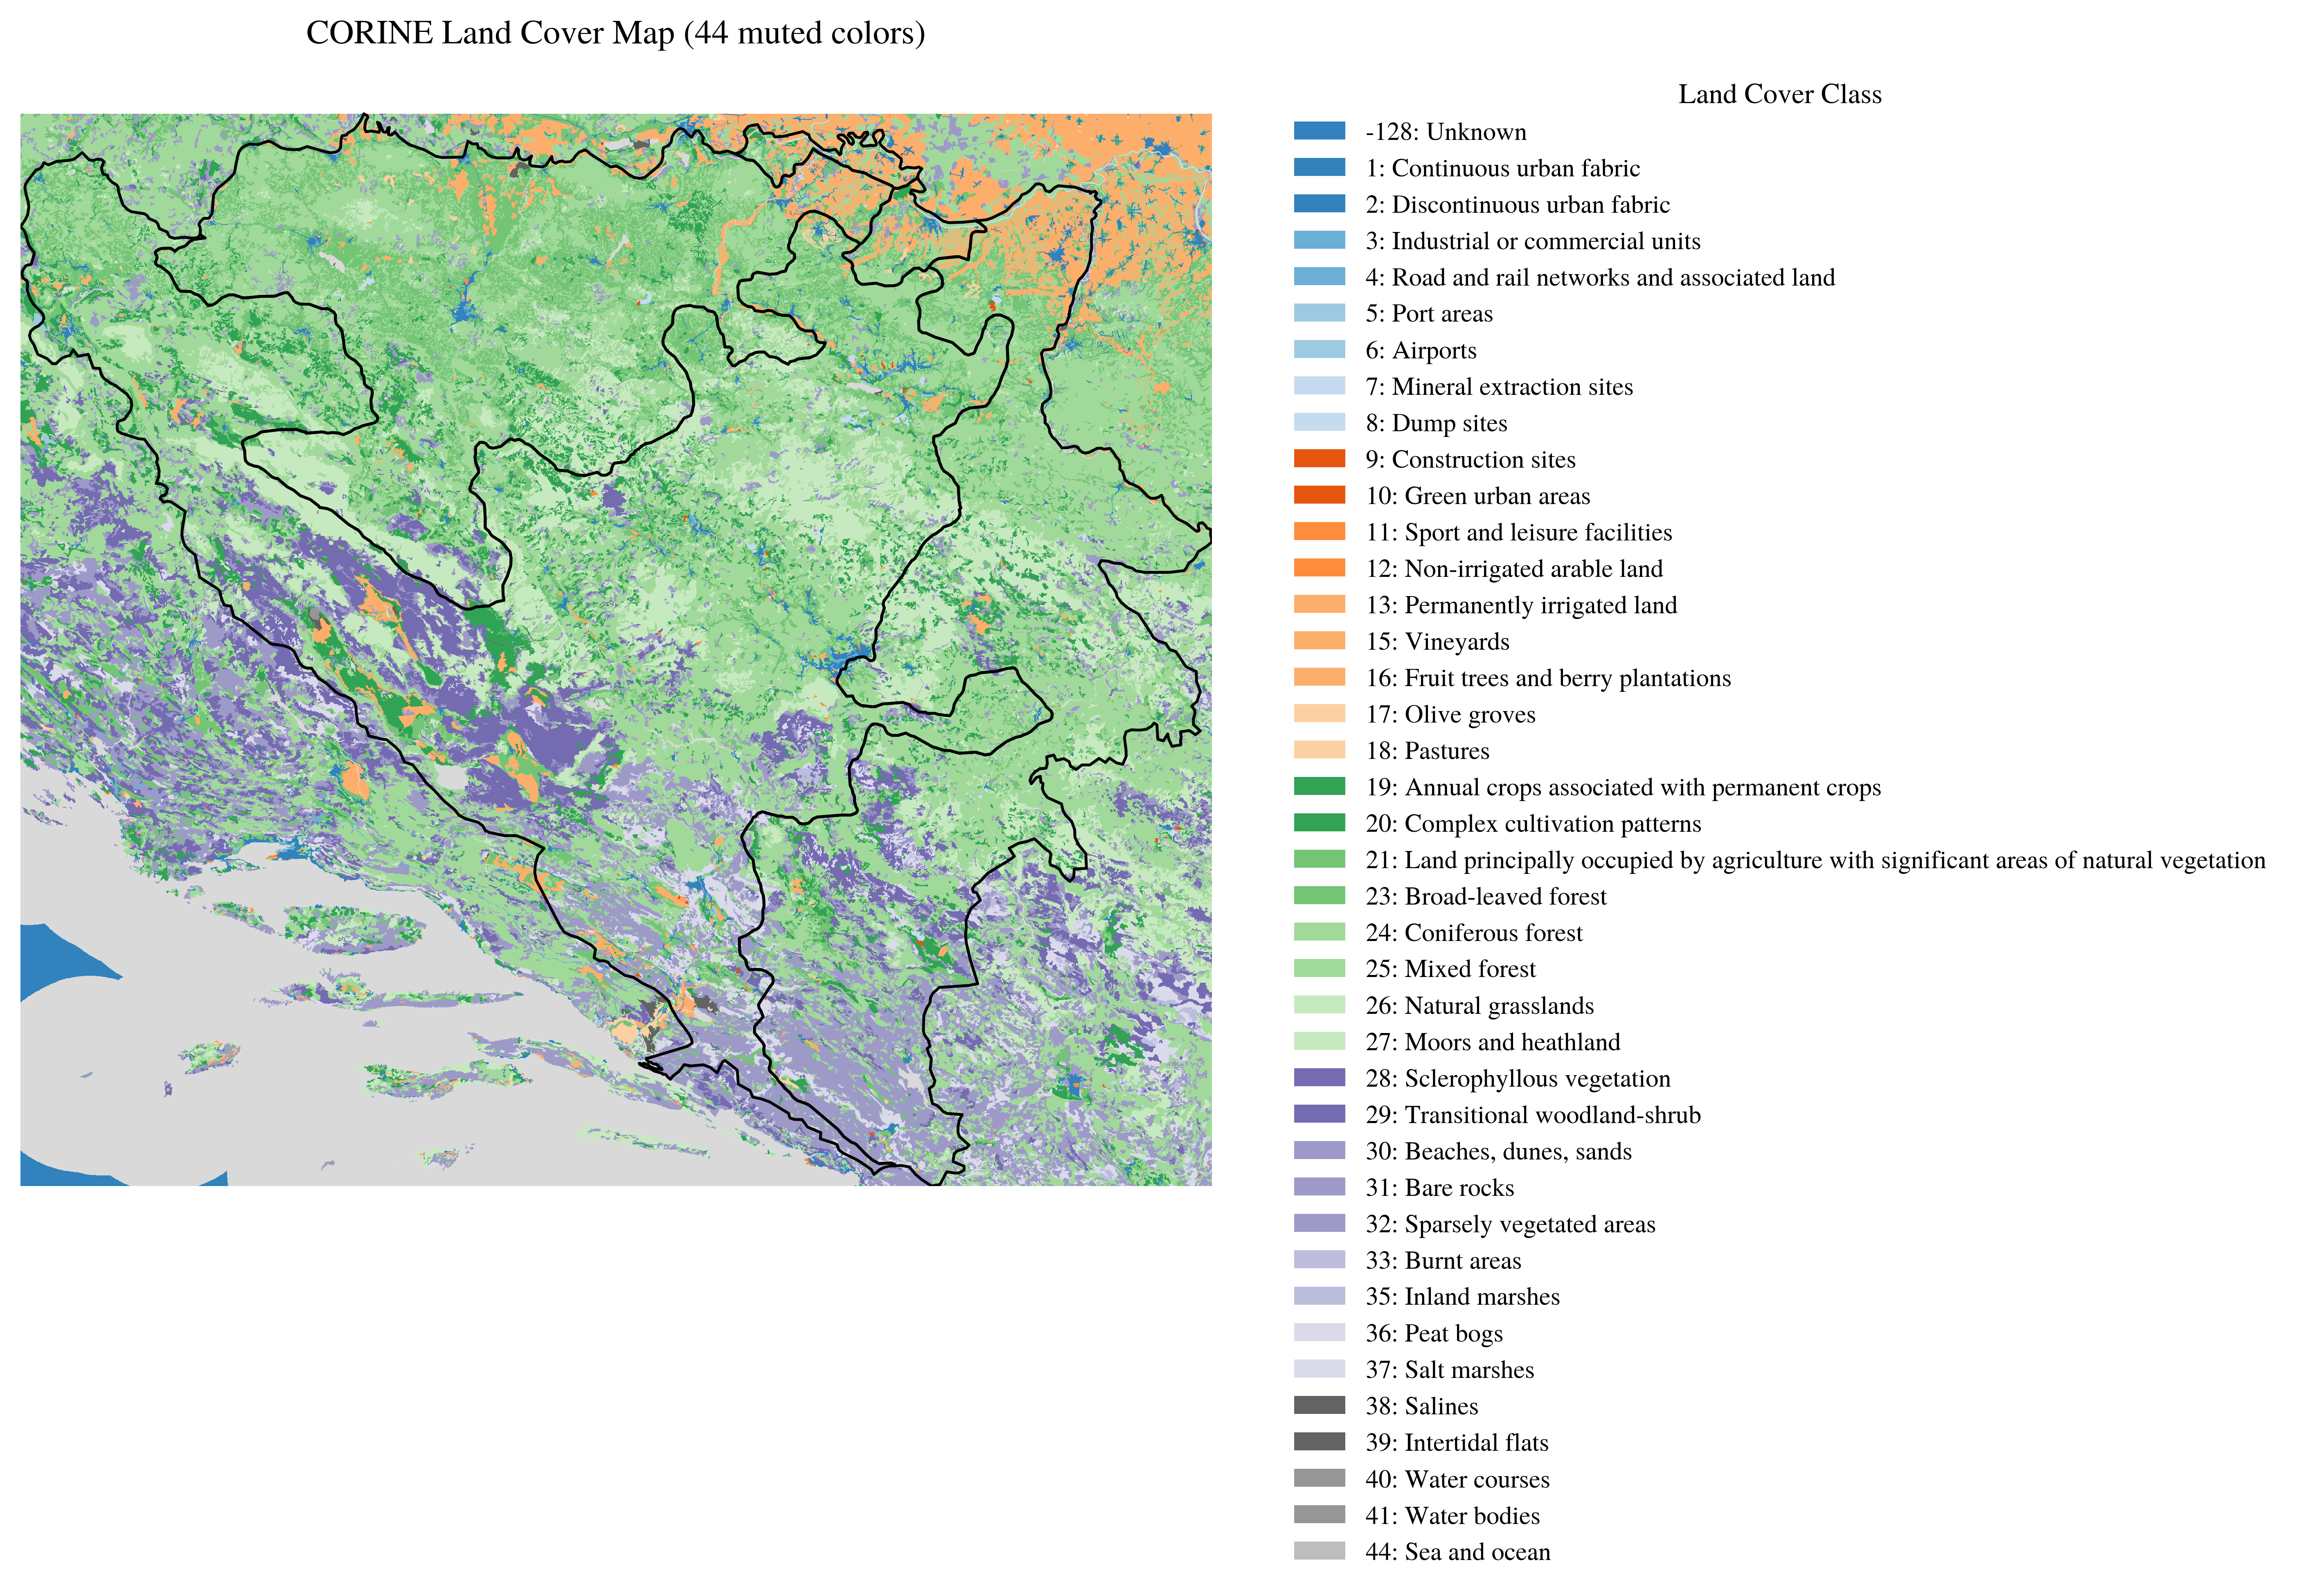

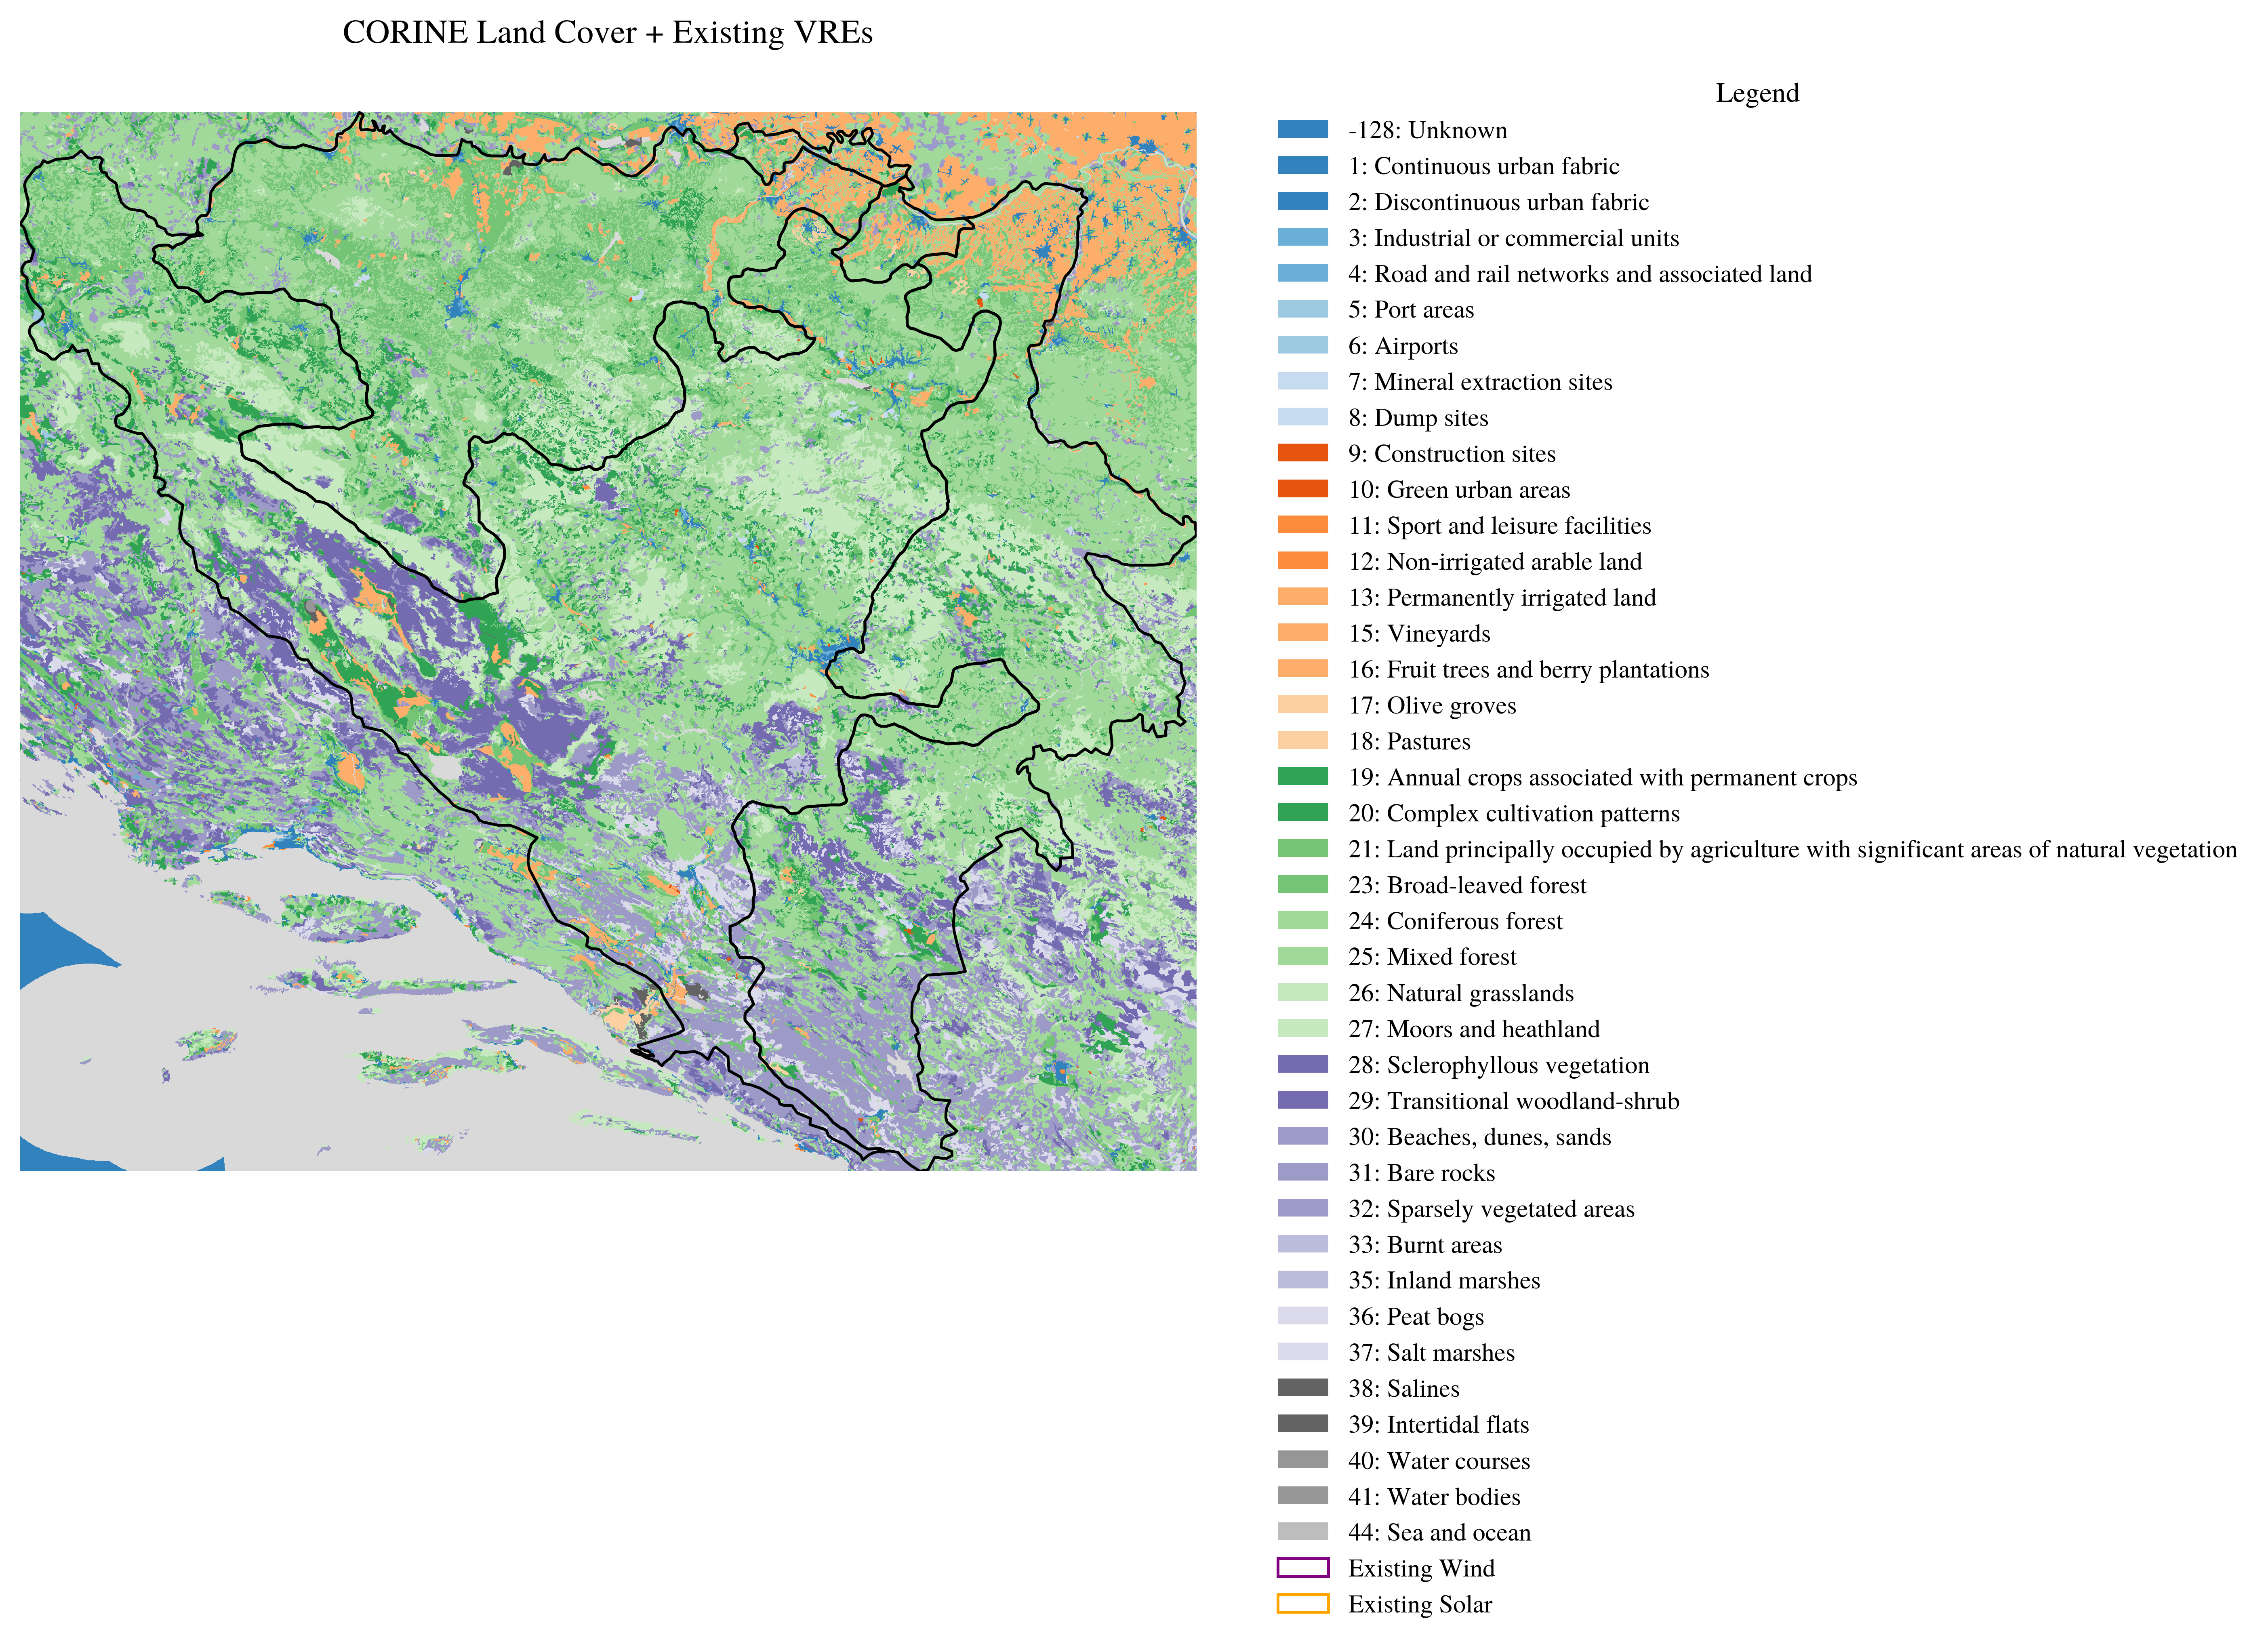

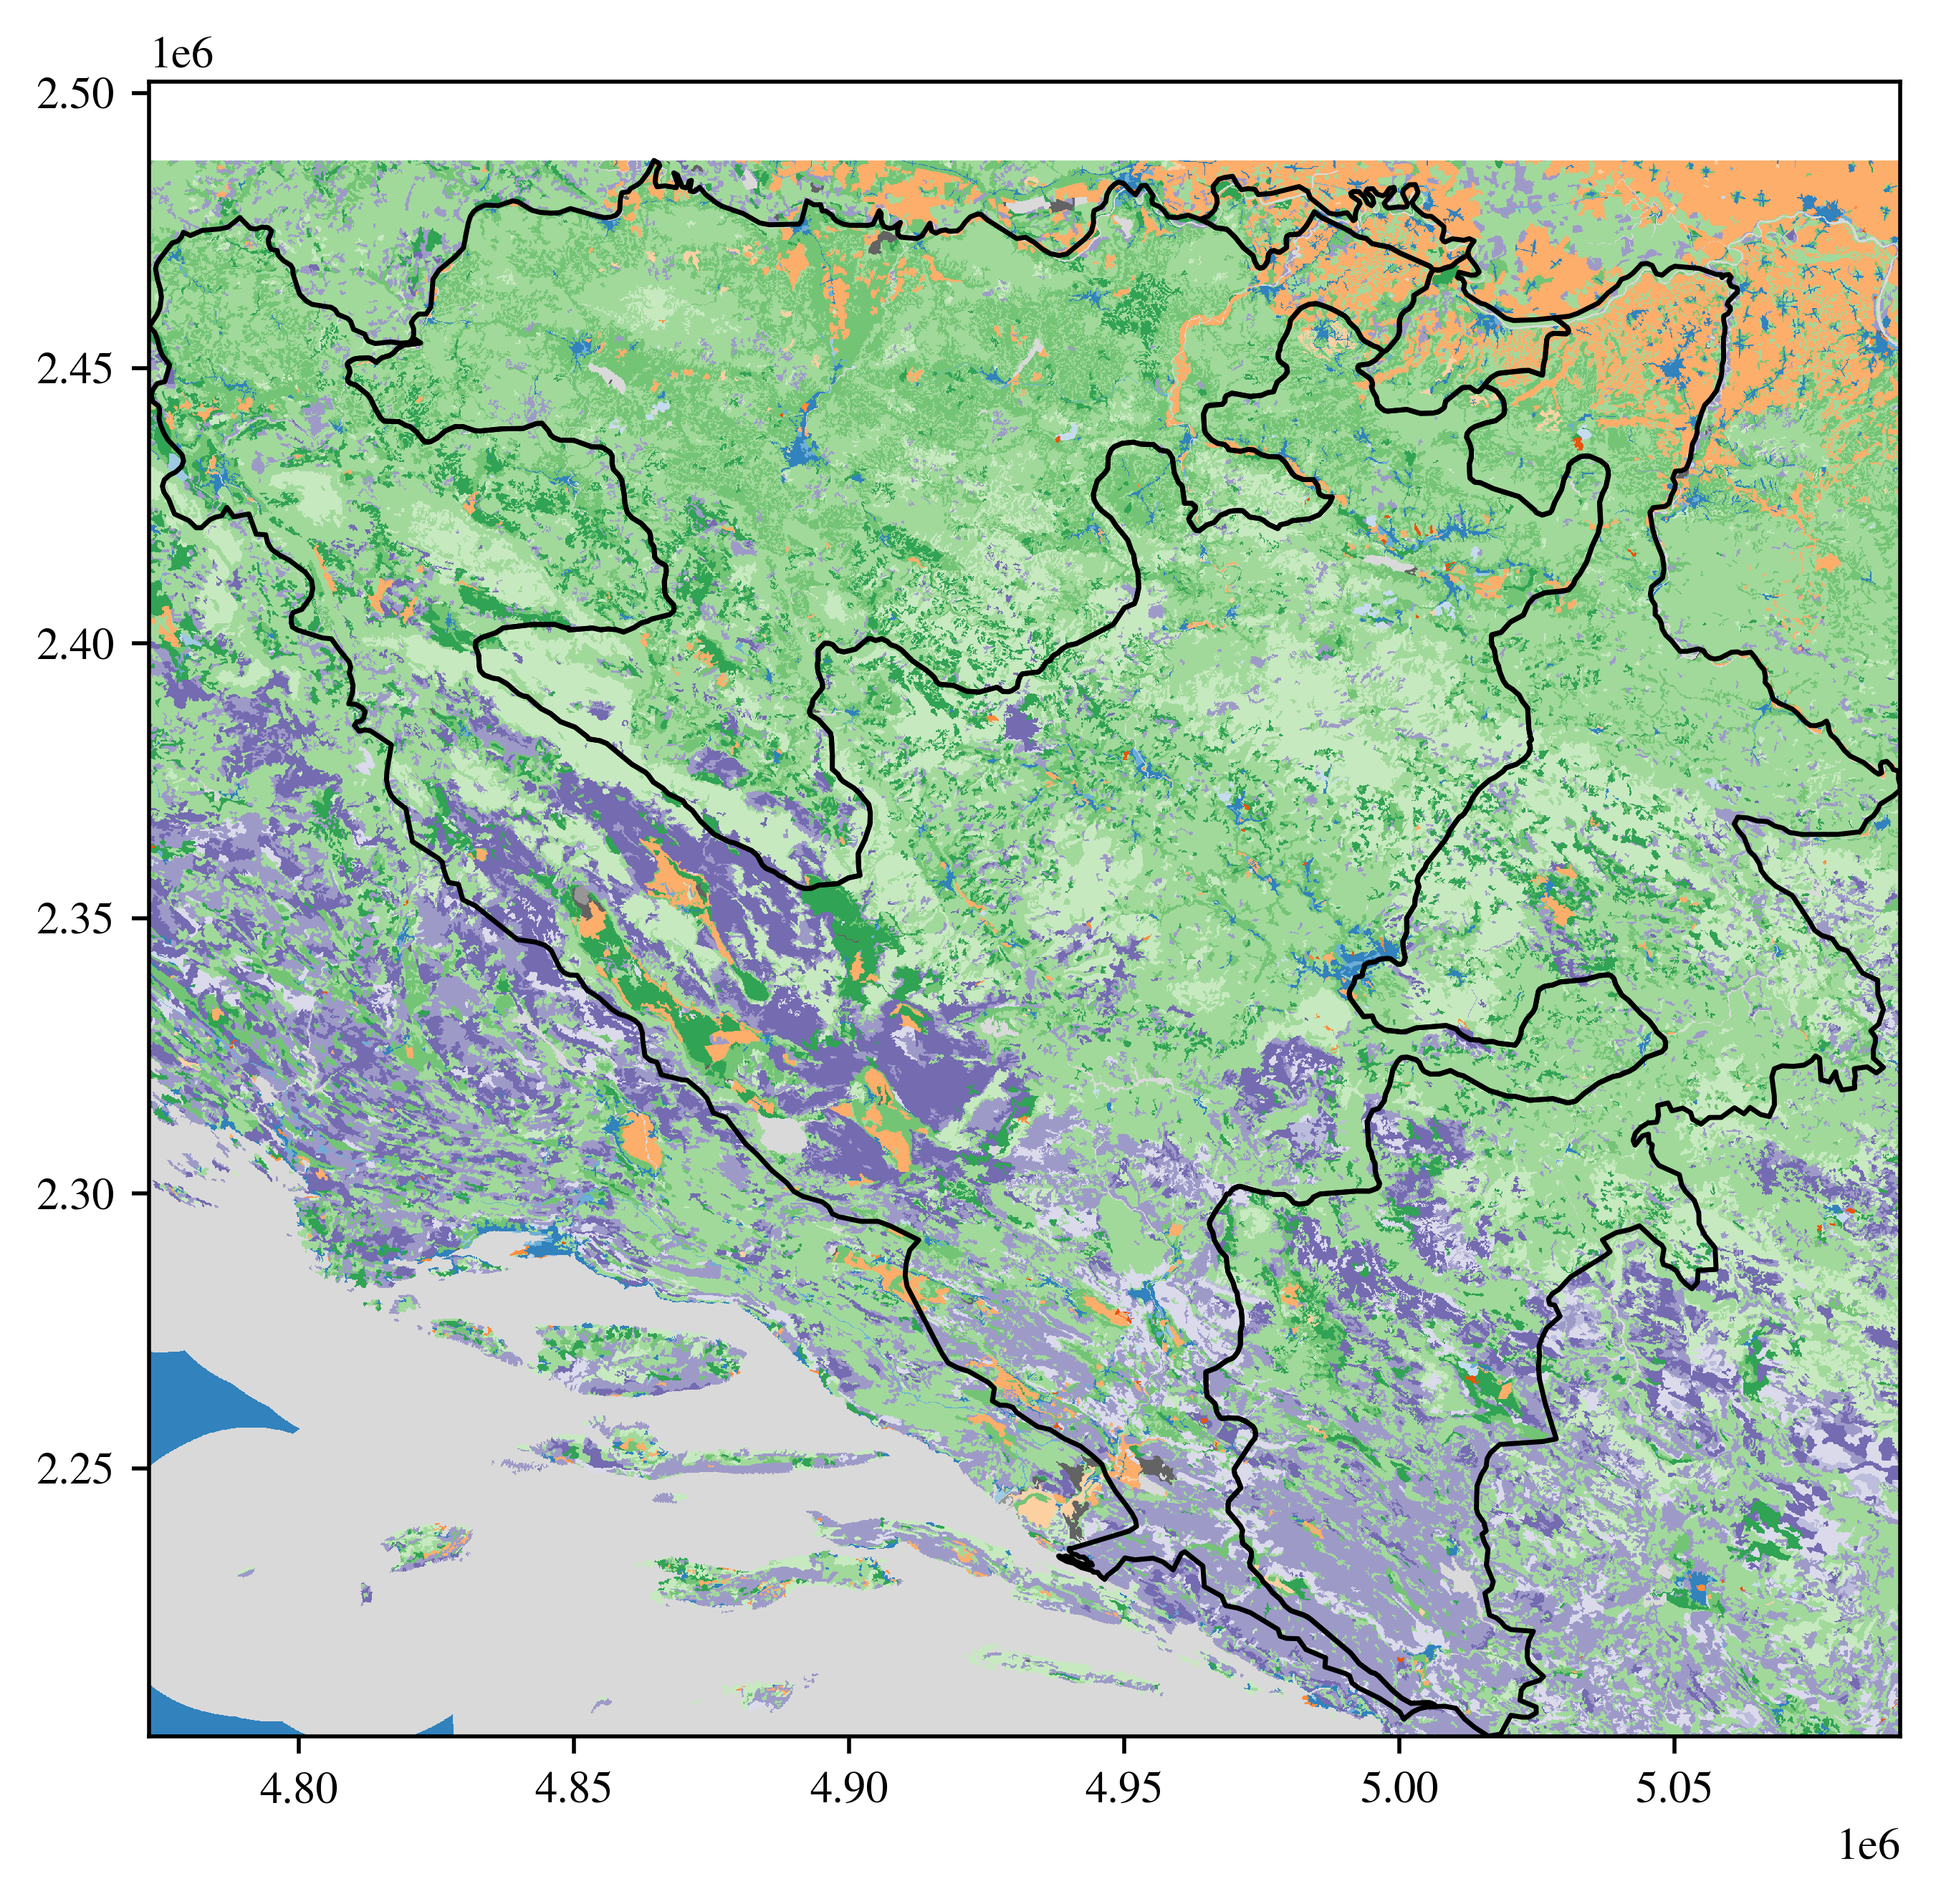

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# --- Raster data (keep NaNs as float) ---
clc = CLC_raster_data.values.squeeze().astype("float32")

present_codes = np.unique(clc[~np.isnan(clc)]).astype(int)
present_codes = [c for c in present_codes if c in mapped_classes]
labels = [mapped_classes[c] for c in present_codes]

# --- Build a "sober" palette: muted but still distinct ---
base_cmap = plt.get_cmap("tab20c")  # or "Paired", "Set3", "viridis"
colors_44 = base_cmap(np.linspace(0, 1, 44))
cmap = ListedColormap(colors_44)

# Map class codes → palette indices
code_to_idx = {c: i % 44 for i, c in enumerate(present_codes)}
clc_idx = np.full_like(clc, np.nan, dtype="float32")
for c, i in code_to_idx.items():
    clc_idx[clc == c] = i

# Raster extent
x = CLC_raster_data.coords["x"].values
y = CLC_raster_data.coords["y"].values
extent = [float(x.min()), float(x.max()), float(y.min()), float(y.max())]
origin = "upper" if y[0] > y[-1] else "lower"

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(clc_idx, extent=extent, origin=origin, cmap=cmap,
               interpolation="nearest", zorder=0)

# Overlay boundary
boundary_X = boundary.to_crs(CLC_raster_data.rio.crs)
boundary_X.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, zorder=2)

# Legend
handles = [Patch(facecolor=cmap(i), label=label) for i, label in enumerate(labels)]
ax.set_title("CORINE Land Cover Map (44 muted colors)")
ax.set_aspect('equal'); ax.axis('off')
plt.tight_layout()
ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', title="Land Cover Class")
# --- Assuming fig, ax already created with raster + boundary ---
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(clc_idx, extent=extent, origin=origin, cmap=cmap,
               interpolation="nearest", zorder=0)

# Overlay boundary
boundary_X = boundary.to_crs(CLC_raster_data.rio.crs)
boundary_X.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, zorder=2)


# Legend: combine raster classes + wind + solar
handles_raster = [Patch(facecolor=cmap(i), label=label) for i, label in enumerate(labels)]
handles_vre = [
    Patch(facecolor='none', edgecolor='purple', label='Existing Wind'),
    Patch(facecolor='none', edgecolor='orange', label='Existing Solar')
]

ax.set_title("CORINE Land Cover + Existing VREs")
ax.set_aspect('equal'); ax.axis('off')
plt.tight_layout()
ax.legend(handles=handles_raster+handles_vre, bbox_to_anchor=(1.05, 1),
          loc='upper left', title="Legend", fontsize=9, frameon=False)

# --- Assuming fig, ax already created with raster + boundary ---
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(clc_idx, extent=extent, origin=origin, cmap=cmap,
               interpolation="nearest", zorder=0)

# Overlay boundary
boundary_X = boundary.to_crs(CLC_raster_data.rio.crs)
boundary_X.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, zorder=2)

# Overlay existing VREs (wind + solar) on SAME axis
existing_VREs_gdf.to_crs(CLC_raster_data.rio.crs)

existing_VREs_gdf[existing_VREs_gdf['type']=='wind'].plot(
    ax=ax, facecolor='none', edgecolor='blue',
    markersize=120, marker='o', label='Existing Wind', alpha=1, zorder=3
)

existing_VREs_gdf[existing_VREs_gdf['type']=='solar'].plot(
    ax=ax, facecolor='none', edgecolor='red',
    markersize=120, marker='s', label='Existing Solar', alpha=1, zorder=3
)

# Legend: combine raster classes + wind + solar
handles_raster = [Patch(facecolor=cmap(i), label=label) for i, label in enumerate(labels)]
handles_vre = [
    Patch(facecolor='none', edgecolor='blue', label='Existing Wind'),
    Patch(facecolor='none', edgecolor='red', label='Existing Solar')
]

ax.set_title("CORINE Land Cover + Existing VREs")
ax.set_aspect('equal'); ax.axis('off')
plt.tight_layout()
ax.legend(handles=handles_raster+handles_vre, bbox_to_anchor=(1.05, 1),
          loc='upper left', title="Legend", fontsize=9, frameon=False)
plt.show()

plt.show()

In [ ]:
# import matplotlib.pyplot as plt

# fig, ax = plt.subplots(figsize=(3.5, 2.5),dpi=500)
# gwa_raster_data.plot(ax=ax, cmap='BuPu', add_colorbar=True)
# boundary.plot(ax=ax, facecolor='none', edgecolor='white', linewidth=0.5)
# ax.set_title("GWA CF-IEC3 Reference (High-res)")
# ax.axis('off')
# plt.savefig(f"../vis/{region_code}/GWA_CF_IEC3.png", bbox_inches='tight', transparent=False)

* Plot wind CF raster (benchmark) vs Calculated CF for ERA5 Cells

In [ ]:
vis.get_CF_wind_check_plot(cells, 
                       gwa_raster_data,
                       boundary,
                       region_code,
                       region_name,
                       ['CF_IEC3', 'wind_CF_mean'],
                       font_family='sans-serif',
                       figure_height=5,)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean and minimal style
sns.set_style("white")

# Initialize the figure
plt.figure(figsize=(7.5, 2.5),dpi=1000)
plt.style.use('../RES/visual_styles/elsevier.mplstyle')

# Create the boxplot
ax = sns.boxplot(
    data=cells[['CF_IEC2', 'CF_IEC3', 'wind_CF_mean']],
    palette="Paired",
    linewidth=0.2,
    width=0.6
)

# Set title and labels
ax.set_title('Capacity Factor Distribution Comparison', weight='semibold', pad=12)
ax.set_ylabel('Capacity Factor')
ax.set_xlabel('')

# Tweak tick formatting
ax.tick_params(axis='x')
ax.tick_params(axis='y')

# Remove all spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Add horizontal grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.xaxis.grid(False)

plt.figtext(
    0.01, -0.08,
    "*'CF_IEC2, CF_IEC3: Average CF for ERA5 Cells, calculated from high-resolution yearly average CF from GWA for IEC Class 2 and 3 turbines.\n"
    "*wind_CF_mean: Average CF for ERA5 Cells, calculated from the ERA5 windspeed (rescaled with GWA) time series ",
    ha='left', fontsize=7, style='normal', fontweight='normal', color='gray',wrap=True
)

plt.tight_layout()
plt.savefig(f"../vis/{region_code}/CF_distribution_comparison.png", bbox_inches='tight', transparent=False)

### CLusters

In [ ]:
clusters_wind_f=clusters_wind[clusters_wind['potential_capacity']>0]
clusters_solar_f=clusters_solar[clusters_solar['potential_capacity']>0]

In [ ]:
print(f'Total sites {len(clusters_wind_f)}')
total_capacity=clusters_wind_f.potential_capacity.sum()
print(f'Total Capacity {int(total_capacity/1E3)} GW')
sites=5
top_sites_capacity=clusters_wind_f.head(sites).potential_capacity.sum()
print(f'Top {sites} sites ({round(sites/len(clusters_wind_f)*100)}% site) capacity {int(top_sites_capacity/1E3)} GW ({round(top_sites_capacity/total_capacity*100)}% of total capacity)')

In [ ]:
print(f'Total sites {len(clusters_solar_f)}')
total_capacity=clusters_solar_f.potential_capacity.sum()
print(f'Total Capacity {int(total_capacity/1E3)} GW')
sites=5
top_sites_capacity=clusters_solar_f.head(sites).potential_capacity.sum()
print(f'Top {sites} sites ({round(sites/len(clusters_solar_f)*100)}% site) capacity {int(top_sites_capacity/1E3)} GW ({round(top_sites_capacity/total_capacity*100)}% of total capacity)')

In [ ]:
clusters_wind_f=clusters_wind[clusters_wind['potential_capacity']>0]
clusters_solar_f=clusters_solar[clusters_solar['potential_capacity']>0]

## Aeroway plots

In [ ]:
aeroway=gpd.read_file(f'../data/downloaded_data/OSM/{region_code}_aeroway.geojson')

In [ ]:
import matplotlib.pyplot as plt

# Shadow effect offset
shadow_offset = 0.008

fig, ax = plt.subplots(figsize=(12,6))



# Plot boundary with shadow effect
boundary.plot(ax=ax, facecolor='none', edgecolor='gray', linewidth=0.3, alpha=1)  # Shadow layer
boundary.geometry = boundary.geometry.translate(xoff=shadow_offset, yoff=-shadow_offset)
boundary.plot(ax=ax, facecolor='none', edgecolor='gray', linewidth=0.2, alpha=0.9)  # Shadow layer
# Plot the aeroway data with more vibrant colors
aeroway.geometry = aeroway.geometry.translate(xoff=-shadow_offset, yoff=shadow_offset)
aeroway.plot('aeroway', legend=True, 
              legend_kwds={'title': "Aeroway Lands with Buffer", 
                           'loc': 'lower left', 
                           'bbox_to_anchor': (.05, 0.45), 
                           'frameon': False, 
                           'prop': {'size': 9}},  # Adjust font size (smaller values make it more compact)
              ax=ax,
              alpha=0.8,
              cmap='Paired')  # Use a vibrant colormap
# Turn off the axis grid
ax.grid(False)
ax.axis('off')
plt.tight_layout()
plt.savefig(f'../vis/{region_code}/lands/Aeroway_{region_code}.png')

## Timeseries


In [ ]:
dissolved_indices_solar=res_data.from_store('dissolved_indices/solar')
cell_ts_solar=res_data.from_store('timeseries/solar')
dissolved_indices_wind=res_data.from_store('dissolved_indices/wind')
cell_ts_wind=res_data.from_store('timeseries/wind')

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def get_cluster_vs_cells_profile(region_to_plot: str, 
                                 cluster_id_to_plot: int,
                                 resource_type:str,
                                 cells_timeseries: pd.DataFrame, 
                                 dissolved_indices: pd.DataFrame, 
                                 cluster_timeseries: pd.DataFrame,
                                 plot_save_to: str | Path = None):
    """
    Plot cluster representative profile vs all member cells as daily mean ± std deviation.

    Parameters
    ----------
    region_to_plot : str
        Region name.
    cluster_id_to_plot : int
        Cluster ID.
    cells_timeseries : pd.DataFrame
        Timeseries for all cells, indexed by datetime.
    dissolved_indices : pd.DataFrame
        Mapping of cells to clusters: dissolved_indices.loc[region, cluster_id] gives list of cell IDs.
    cluster_timeseries : pd.DataFrame
        Cluster representative timeseries, indexed by datetime.
    plot_save_to : str | Path, optional
        Path to save figure. If None, figure is saved under `./vis/`.
    """
    resource_type = resource_type.lower()
    if resource_type not in ['solar', 'wind']:
        raise ValueError("resource_type must be either 'solar' or 'wind'")
    region = region_to_plot
    cluster_id = cluster_id_to_plot

    # --- 1. GET MEMBER CELLS OF THE CLUSTER ---
    cell_ids = dissolved_indices.loc[region, cluster_id]

    # --- 2. RESAMPLE TO DAILY MEAN ---
    cell_daily = [cells_timeseries[cid].resample("1D").mean() for cid in cell_ids]
    cluster_daily = cluster_timeseries[f"{region}_{cluster_id}"].resample("1D").mean()

    # --- 3. CONVERT TO 2D ARRAY (days × cells) ---
    cell_matrix = np.column_stack([s.values for s in cell_daily])

    # --- 4. CALCULATE DAILY MEAN AND STD DEV ---
    mean_cells = cell_matrix.mean(axis=1)
    std_cells = cell_matrix.std(axis=1)

    # --- 5. PLOT ---
    fig, ax = plt.subplots(figsize=(12, 3.5), dpi=300)

    # Shaded area: ±1 std deviation
    ax.fill_between(cell_daily[0].index, mean_cells - std_cells, mean_cells + std_cells,
                    color="orange" if resource_type=='solar' else "skyblue", alpha=0.3, label="Cells ±1 Std Dev")

    # Cluster representative
    ax.plot(cluster_daily.index, cluster_daily.values, color="orangered" if resource_type=='solar' else "navy", linewidth=2, label="Cluster Profile")

    # Clean aesthetics
    ax.set_title(f"Daily Mean {resource_type.capitalize()} Profiles – {region} Cluster {cluster_id}", fontsize=14, weight="bold")
    # ax.set_xlabel("Day of Year", fontsize=12)
    ax.set_ylabel("Normalized Generation", fontsize=12)
    ax.grid(alpha=0.4,linestyle='--', linewidth=0.5)
    ax.legend(frameon=False)
    ax.tick_params(axis="both", which="major", labelsize=10,labelrotation =90,direction='in',length=3)

    # Optional: make background transparent
    # fig.patch.set_alpha(0)
    # ax.set_facecolor('none')

    plt.tight_layout()

    # --- 6. SAVE FIGURE ---
    if plot_save_to is None:
        plot_save_to = Path(f'../vis/{region_code}/{resource_type}_cluster_{region}_{cluster_id}_vs_cells_profile.png')
    else:
        plot_save_to = Path(plot_save_to)

    plot_save_to.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(plot_save_to)
    utils.print_update(level=2, message=f"Cluster vs Cells profile plot saved to {plot_save_to}")
    plt.show()

In [ ]:
get_cluster_vs_cells_profile('EastKootenay', 1, 'solar',cell_ts_solar, dissolved_indices_solar, timeseries_clusters_solar)
get_cluster_vs_cells_profile('PeaceRiver', 1, 'wind',cell_ts_wind, dissolved_indices_wind, timeseries_clusters_wind)

# Energy Calculations

In [ ]:
cells['potential_energy_solar_GWh']=cells['potential_capacity_solar']*cells['solar_CF_mean']*8760/1E3 # GWh
cells['potential_energy_wind_GWh']=cells['potential_capacity_wind']*cells['wind_CF_mean']*8760/1E3 # GWh

solar_total=cells['potential_capacity_solar'].sum()/1E3
wind_total=cells['potential_capacity_wind'].sum()/1E3

print(f"Total potential solar capacity: {solar_total:.2f} GW")
print(f"Total potential wind capacity: {wind_total:.2f} GW")

### Proximity Range Filters

In [ ]:
# GRID_PROXIMITY_KM:int=30 #km
# cells_grid_proximity_filtered=cells[cells['nearest_distance']<=GRID_PROXIMITY_KM]

# solar_total_filtered=cells_grid_proximity_filtered['potential_capacity_solar'].sum()/1E3
# wind_total_filtered=cells_grid_proximity_filtered['potential_capacity_wind'].sum()/1E3

# print(f"Total potential solar capacity @ {GRID_PROXIMITY_KM}km grid proximity: {solar_total_filtered:.2f} GW")
# print(f"Total potential wind capacity @ {GRID_PROXIMITY_KM}km grid proximity: {wind_total_filtered:.2f} GW")

## Supply Curve Analytics

* Check the scores

In [ ]:
cells[cells['potential_capacity_solar']>0].describe()['lcoe_solar']

In [ ]:
cells[cells['potential_capacity_wind']>0].describe()['lcoe_wind']

- Analysing solar resource's supply curve

In [ ]:
energy_threshold_solar=4000 #GWh
energy_threshold_wind=5000 #GWh

In [ ]:
cells_solar_sorted = cells[cells['potential_capacity_solar']>0].sort_values(by='lcoe_solar')
solar_cumsum = cells_solar_sorted['potential_energy_solar_GWh'].cumsum()
cells_until_energy_threshold_solar = cells_solar_sorted.loc[solar_cumsum <= energy_threshold_solar]

print(f"Total potential solar energy: {cells_until_energy_threshold_solar['potential_energy_solar_GWh'].sum():.2f} GWh")
print(f"Number of cells needed (solar): {len(cells_until_energy_threshold_solar)}")
print(f" {cells_until_energy_threshold_solar.potential_capacity_solar.sum()/1E3:.2f} GW potential solar capacity")
print(f" Mean Score : {cells_until_energy_threshold_solar.lcoe_solar.mean():.2f} $/MWH")
cells_until_energy_threshold_solar.lcoe_solar.describe()

- Analysing wind resource's supply curve

In [ ]:
cells_wind_sorted = cells[cells['potential_capacity_wind']>0].sort_values(by='lcoe_wind')
wind_cumsum = cells_wind_sorted['potential_energy_wind_GWh'].cumsum()
cells_until_energy_threshold_wind = cells_wind_sorted.loc[wind_cumsum <= energy_threshold_wind]

print(f"Total potential wind energy: {cells_until_energy_threshold_wind['potential_energy_wind_GWh'].sum():.2f} GWh")
print(f"Number of cells needed (wind): {len(cells_until_energy_threshold_wind)}")
print(f" {cells_until_energy_threshold_wind.potential_capacity_wind.sum()/1E3:.2f} GW potential wind capacity")
print(f" {cells_until_energy_threshold_wind.potential_capacity_wind.sum()/1E3:.2f} GW potential wind capacity")
print(f" Mean Score : {cells_until_energy_threshold_wind.lcoe_wind.mean():.2f} $/MWH")
cells_until_energy_threshold_wind.lcoe_wind.describe()

In [ ]:
lcoe_threshold_solar:int=75 #$/MWH
lcoe_threshold_wind:int=180 #$/MWH

solar_cells_filtered = cells[cells['lcoe_solar'] <= lcoe_threshold_solar]
wind_cells_filtered = cells[cells['lcoe_wind'] <= lcoe_threshold_wind]
solar_cells_filtered.to_csv(f"../results/RESources/{country_kwd}/{region_code}/solar_cells_below_{lcoe_threshold_solar}_$pMWh_{region_code}_{RUN_ID}.csv",index=False)
print(f"Saved filtered cells to ../results/RESources/{country_kwd}/{region_code}/solar_cells_below_{lcoe_threshold_solar}_$pMWh_{region_code}_{RUN_ID}.csv"    )
wind_cells_filtered.to_csv(f"../results/RESources/{country_kwd}/{region_code}/wind_cells_below_{lcoe_threshold_wind}_$pMWh_{region_code}_{RUN_ID}.csv",index=False)
print(f"Saved filtered cells to ../results/RESources/{country_kwd}/{region_code}/wind_cells_below_{lcoe_threshold_wind}_$pMWh_{region_code}_{RUN_ID}.csv"    )

print(f"Total potential solar capacity <={lcoe_threshold_solar} $/MWh LCOE threshold: {solar_cells_filtered['potential_capacity_solar'].sum()/1E3:.2f} GW")
print(f"Total potential wind capacity <={lcoe_threshold_wind} $/MWh LCOE threshold: { wind_cells_filtered['potential_capacity_wind'].sum()/1E3:.2f} GW")


print(f"Total potential solar energy @ <={lcoe_threshold_solar} $/MWh LCOE threshold: {solar_cells_filtered['potential_energy_solar_GWh'].sum():.2f} GWh")
print(f"Total potential wind energy @ <={lcoe_threshold_wind} $/MWh LCOE threshold: {wind_cells_filtered['potential_energy_wind_GWh'].sum():.2f} GWh")

- Extract the co-located Resources (cells)

In [ ]:
common_idx = solar_cells_filtered.index.intersection(wind_cells_filtered.index)
solar_common_capacity = solar_cells_filtered.loc[common_idx, 'potential_capacity_solar'].sum() / 1E3
wind_common_capacity = wind_cells_filtered.loc[common_idx, 'potential_capacity_wind'].sum() / 1E3
timeseries_solar_filtered=timeseries_solar[common_idx]
timeseries_wind_filtered=timeseries_wind[common_idx]
print(f"Common index count: {len(common_idx)}")
print(f"Solar capacity (GW) in common cells: {solar_common_capacity:.2f}")
print(f"Wind capacity (GW) in common cells: {wind_common_capacity:.2f}")

In [ ]:
solar_cells_filtered_default= pd.read_csv(f"../results/RESources/{country_kwd}/{region_code}/solar_cells_below_{lcoe_threshold_solar}_$pMWh_{region_code}_default.csv")
wind_cells_filtered_default = pd.read_csv(f"../results/RESources/{country_kwd}/{region_code}/wind_cells_below_{lcoe_threshold_wind}_$pMWh_{region_code}_default.csv")

In [ ]:
# import matplotlib.pyplot as plt

# # Prepare supply curve data for solar
# solar_sorted = solar_cells_filtered.sort_values(by='lcoe_solar')
# solar_cumsum_energy = solar_sorted['potential_energy_solar_GWh'].cumsum()
# solar_lcoe = solar_sorted['lcoe_solar']

# # Prepare supply curve data for wind
# wind_sorted = wind_cells_filtered.sort_values(by='lcoe_wind')
# wind_cumsum_energy = wind_sorted['potential_energy_wind_GWh'].cumsum()
# wind_lcoe = wind_sorted['lcoe_wind']

# # Plot
# fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# # Smooth lines with consistent style
# ax.plot(solar_cumsum_energy, solar_lcoe, label='Solar', color='#FF8C00', linewidth=2.2)
# ax.plot(wind_cumsum_energy, wind_lcoe, label='Wind', color='#1f3b73', linewidth=2.2)

# # Labels and title
# ax.set_xlabel('Cumulative Potential Energy (GWh)', fontsize=12, labelpad=8)
# ax.set_ylabel('LCOE ($/MWh)', fontsize=12, labelpad=8)
# ax.set_title('Supply Curve of Solar and Wind', fontsize=14, weight='bold', pad=12)

# # Gridlines: light, behind data
# ax.grid(alpha=0.25, linestyle='--', linewidth=0.7, zorder=0)

# # Legend: outside and clean
# ax.legend(frameon=False, fontsize=11, loc='upper left')

# # Remove spines for minimalism
# for spine in ['top', 'right']:
#     ax.spines[spine].set_visible(False)

# # Tight layout
# plt.tight_layout()
# plt.show()


In [ ]:
import matplotlib.pyplot as plt

# --- Prepare supply curve data (technical potential) ---
solar_sorted = solar_cells_filtered.sort_values(by='lcoe_solar')
solar_cumsum_energy = solar_sorted['potential_energy_solar_GWh'].cumsum()
solar_lcoe = solar_sorted['lcoe_solar']

wind_sorted = wind_cells_filtered.sort_values(by='lcoe_wind')
wind_cumsum_energy = wind_sorted['potential_energy_wind_GWh'].cumsum()
wind_lcoe = wind_sorted['lcoe_wind']

# --- Prepare policy-constrained curves ---
solar_sorted_default = solar_cells_filtered_default.sort_values(by='lcoe_solar')
solar_cumsum_energy_default = solar_sorted_default['potential_energy_solar_GWh'].cumsum()
solar_lcoe_default = solar_sorted_default['lcoe_solar']

wind_sorted_default = wind_cells_filtered_default.sort_values(by='lcoe_wind')
wind_cumsum_energy_default = wind_sorted_default['potential_energy_wind_GWh'].cumsum()
wind_lcoe_default = wind_sorted_default['lcoe_wind']

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# Policy-constrained (dashed lines)
ax.plot(solar_cumsum_energy, solar_lcoe, 
        label='Solar (Policy-constrained)', color='#FF8C00', linestyle='--', linewidth=2.2)
ax.plot(wind_cumsum_energy, wind_lcoe, 
        label='Wind (Policy-constrained)', color='#1f3b73', linestyle='--', linewidth=2.2)

# Baseline (faded solid lines)
ax.plot(solar_cumsum_energy_default, solar_lcoe_default, 
        label='Solar (Baseline)', color='#FF8C00', linewidth=2.2, alpha=0.5)
ax.plot(wind_cumsum_energy_default, wind_lcoe_default, 
        label='Wind (Baseline)', color='#1f3b73', linewidth=2.2, alpha=0.5)


# Labels and title
ax.set_xlabel('Cumulative Potential Energy (GWh)', fontsize=12, labelpad=8)
ax.set_ylabel('LCOE ($/MWh)', fontsize=12, labelpad=8)
ax.set_title('Supply Curve of Solar and Wind\nTechnical vs. Policy-Constrained Potential',
             fontsize=14, weight='bold', pad=12)

# Limit X axis to 20,000 GWh
# ax.set_xlim(0, 40000)


# Legend
ax.legend(frameon=False, fontsize=11, loc='upper right')

# Minimalist spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
# plt.show()

# Create Visuals

# Temporal Analysis

* All cells

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

# -----------------------------------------
# 1) DATA: compute both matrices + scores
# -----------------------------------------
def compute_region_complementarity(
    timeseries_solar: pd.DataFrame,
    timeseries_wind:  pd.DataFrame,
    region: str | None = None,
    extract_region_fn=None,  # callable: str -> region label; optional
):
    """
    Returns both hour×month matrices + complementarity scores.

    Outputs dict:
      {
        'meta': {'region_label', 'n_sites'},
        'pearson': {'matrix': pearson_mat (24×12), 'pearson_C': float},
        'diff':    {'matrix': diff_mat (24×12),    'diff_C': float}
      }
    """

    # --- Align indices ---
    idx = timeseries_solar.index.intersection(timeseries_wind.index)
    if len(idx) == 0:
        raise ValueError("Solar and wind time indices do not overlap.")
    ts_solar_full = timeseries_solar.loc[idx]
    ts_wind_full  = timeseries_wind.loc[idx]

    # --- Region filter helper ---
    def _select_cols(cols, region_label):
        if region_label is None:
            return list(cols)
        if extract_region_fn is not None:
            return [c for c in cols if extract_region_fn(c) == region_label]
        # fallback: substring match
        region_label = str(region_label)
        return [c for c in cols if region_label in str(c)]

    solar_cols = _select_cols(ts_solar_full.columns, region)
    wind_cols  = _select_cols(ts_wind_full.columns,  region)
    common_cols = sorted(set(solar_cols).intersection(set(wind_cols)))
    if len(common_cols) == 0:
        raise ValueError(f"No common site columns for region={region!r}. Check column names / extract_region().")

    # --- Aggregate across selected sites ---
    solar_mean = ts_solar_full[common_cols].mean(axis=1)
    wind_mean  = ts_wind_full[common_cols].mean(axis=1)

    # --- Helper: build hour×month matrix(s) ---
    def _to_hour_month_matrix(series: pd.Series) -> pd.DataFrame:
        df = pd.DataFrame({'value': series})
        df['hour'] = df.index.hour
        df['month'] = df.index.month
        mat = df.groupby(['hour','month'], observed=True)['value'].mean().unstack('month')
        return mat.reindex(index=range(24), columns=range(1, 13))

    def _hour_month_corr(a: pd.Series, b: pd.Series) -> pd.DataFrame:
        df = pd.DataFrame({'solar': a, 'wind': b}).dropna()
        df['hour'] = df.index.hour
        df['month'] = df.index.month

        def _corr(g):
            if (g['solar'].std(ddof=0) == 0) or (g['wind'].std(ddof=0) == 0):
                return np.nan
            return g['solar'].corr(g['wind'])

        r = df.groupby(['hour', 'month'], observed=True).apply(_corr).unstack('month')
        return r.reindex(index=range(24), columns=range(1, 13))

    # --- Matrices ---
    pearson_mat = _hour_month_corr(solar_mean, wind_mean)                 # in [-1, 1]
    solar_mat   = _to_hour_month_matrix(solar_mean)
    wind_mat    = _to_hour_month_matrix(wind_mean)

    # Normalize for dominance map
    solar_norm = solar_mat / np.nanmax(solar_mat.values)
    wind_norm  = wind_mat  / np.nanmax(wind_mat.values)
    diff_mat   = solar_norm - wind_norm                                   # [-1, 1] approx

    # --- Complementarity scores (scalars) ---
    # Pearson-based complementarity: average anti-correlation (negative r)
    pearson_C = np.nanmean(np.clip(-pearson_mat.values, 0, 1))            # 0–1 (higher = more complementary)

    # Diff-based complementarity: average absolute dominance difference
    diff_C = np.nanmean(np.abs(diff_mat.values))                          # 0–1 (higher = stronger diurnal-seasonal offset)

    return {
        'meta': {
            'region_label': region if region is not None else "All Regions",
            'n_sites': len(common_cols),
        },
        'pearson': {
            'matrix': pearson_mat,
            'pearson_C': float(pearson_C),
        },
        'diff': {
            'matrix': diff_mat,
            'diff_C': float(diff_C),
        }
    }

# -----------------------------------------
# 2) PLOT: consume any precomputed matrix
# -----------------------------------------
def plot_complementarity_heatmap(
    mat: pd.DataFrame,
    metric: str = "pearson",                   # "pearson" or "diff"
    region_label: str = "All Regions",
    n_sites: int | None = None,
    clusters: bool = True,
    font_family: str | None = None,
    style_path: str | None = None,
    show: bool = True,
):
    sns.set_theme(style="whitegrid")
    sns.set_palette("Set2")
    if font_family is not None:
        plt.rcParams['font.family'] = font_family
    if style_path:
        try:
            plt.style.use(style_path)
        except Exception:
            pass

    # Diverging cmap for "diff" metric (as in your earlier code)
    colors_neg = plt.cm.PuBu(np.linspace(0.3, 1, 128))
    colors_pos = plt.cm.OrRd(np.linspace(0.3, 1, 128))
    colors = np.vstack((colors_neg[::-1], colors_pos))
    custom_cmap = LinearSegmentedColormap.from_list('WindSolarDiv', colors)

    # Ranges and labels
    if metric.lower() == "pearson":
        vmin, vmax, center = -1.0, 1.0, 0.0
        cmap = "coolwarm"
        cbar_label = "Pearson r (negative = complementary)"
        title_metric = "Pearson r"
    elif metric.lower() == "diff":
        vmin, vmax, center = -0.8, 0.8, 0.0
        cmap = custom_cmap
        cbar_label = 'Resource Dominance\n(Purple: Wind | Orange: Solar)'
        title_metric = "Solar–Wind Dominance"
    else:
        raise ValueError("metric must be 'pearson' or 'diff'.")

    month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    fig, ax = plt.subplots(figsize=(9, 5), dpi=500)
    sns.heatmap(
        mat, cmap=cmap, vmin=vmin, vmax=vmax, center=center,
        linewidths=0, cbar_kws={'label': cbar_label, 'shrink': 0.8}, ax=ax
    )

    ax.set_xticks(np.arange(12) + 0.5)
    ax.set_xticklabels(month_names, rotation=90, fontsize=9)
    ax.set_yticks(np.arange(0, 24, 4) + 0.5)
    ax.set_yticklabels(np.arange(0, 24, 4), fontsize=9)
    ax.set_xlabel('Month', fontsize=9, fontweight='bold')
    ax.set_ylabel('Hour of Day', fontsize=9, fontweight='bold')
    ax.set_title(f'{region_label} | {title_metric}', fontsize=14, fontweight='bold')

    # Annotation badge
    if n_sites is not None:
        annotation_custom = 'Representative Clustered Sites Nos:' if clusters else 'ERA5 Cells Nos:'
        ax.text(0.02, 0.97, f'{annotation_custom} {n_sites}', transform=ax.transAxes,
                ha='left', va='bottom', fontsize=8, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightgrey', alpha=0.7))

    # KEEP OLD ANNOTATIONS for "diff"
    if metric.lower() == "diff":
        # Peak solar and wind periods (original rectangles & labels)
        ax.add_patch(Rectangle((0,10),12,6, linewidth=1.5, edgecolor='orange',
                               facecolor='none', linestyle='--', alpha=0.8))
        ax.text(6, 8.5, 'Solar Peak\nDay', ha='center', va='center', fontsize=7, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='orange', alpha=0.7))

        ax.add_patch(Rectangle((0,0),12,6, linewidth=1.5, edgecolor='lightblue',
                               facecolor='none', linestyle='--', alpha=0.8))
        ax.text(6, 3, 'Wind Dominant\nNight', ha='center', va='center', fontsize=7, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.7))

        ax.add_patch(Rectangle((0,18),12,6, linewidth=1.5, edgecolor='lightblue',
                               facecolor='none', linestyle='--', alpha=0.8))
        ax.text(6, 21, 'Wind Dominant\nEve', ha='center', va='center', fontsize=7, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.7))

        # Seasonal annotations (kept as in prior code)
        ax.text(1.5, 28.2, 'Winter', ha='center', va='center', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcyan', alpha=0.8))
        ax.text(5.5, 28.2, 'Summer', ha='center', va='center', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
        ax.text(9.5, 28.2, 'Fall', ha='center', va='center', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.8))

    plt.tight_layout()
    if show:
        plt.show()
    return fig, ax

# -----------------------------------------
# 3) Optional wrapper with old signature
# -----------------------------------------
def plot_region_complementarity(
    timeseries_solar: pd.DataFrame,
    timeseries_wind:  pd.DataFrame,
    region_code: str,
    RUN_ID: str = 'default',
    region: str | None = None,
    clusters: bool = True,
    aggregate: bool = False,   # kept for signature compatibility
    show: bool = True,
    font_family: str | None = None,
    metric: str = "pearson",
    extract_region_fn=None,
    style_path: str | None = None,
):
    results = compute_region_complementarity(
        timeseries_solar, timeseries_wind, region=region, extract_region_fn=extract_region_fn
    )
    if metric.lower() == "pearson":
        mat = results['pearson']['matrix']
        cval = results['pearson']['pearson_C']
        title = f"{results['meta']['region_label']} | Pearson r | Complementarity Score: {cval:.2f}"
    elif metric.lower() == "diff":
        mat = results['diff']['matrix']
        cval = results['diff']['diff_C']
        title = f"{results['meta']['region_label']} | Solar–Wind Dominance | Complementarity Score: {cval:.2f}"
    else:
        raise ValueError("metric must be 'pearson' or 'diff'.")

    fig, ax = plot_complementarity_heatmap(
        mat=mat, metric=metric, region_label=results['meta']['region_label'],
        n_sites=results['meta']['n_sites'], clusters=clusters,
        font_family=font_family, style_path=style_path, show=show
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    return results, (fig, ax)


In [ ]:
results, _ = plot_region_complementarity(
    timeseries_solar, timeseries_wind,
    region_code=region_code, RUN_ID="v1",
    # region="PeaceRiver",
    metric="diff", show=False,
    extract_region_fn=vis.extract_region
)


pearson_C = results['pearson']['pearson_C']
diff_C    = results['diff']['diff_C']


In [ ]:
import numpy as np
import pandas as pd
from typing import Literal, Optional

# ---------- helpers ----------
def _to_hour_month_matrix(series: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame({'value': series})
    df['hour'] = df.index.hour
    df['month'] = df.index.month
    mat = df.groupby(['hour','month'], observed=True)['value'].mean().unstack('month')
    return mat.reindex(index=range(24), columns=range(1, 13))

def _hour_month_corr(a: pd.Series, b: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame({'solar': a, 'wind': b}).dropna()
    df['hour'] = df.index.hour
    df['month'] = df.index.month

    def _corr(g):
        if (g['solar'].std(ddof=0) == 0) or (g['wind'].std(ddof=0) == 0):
            return np.nan
        return g['solar'].corr(g['wind'])

    r = df.groupby(['hour','month'], observed=True).apply(_corr).unstack('month')
    return r.reindex(index=range(24), columns=range(1, 13))

def _build_weights(
    weighting: Literal["none","demand","cf","energy"] = "none",
    demand_ts: Optional[pd.Series] = None,
    solar_mat: Optional[pd.DataFrame] = None,
    wind_mat: Optional[pd.DataFrame] = None
) -> pd.DataFrame:
    """
    Returns non-negative 24x12 weights that sum to 1 (NaNs treated as 0).
    - "none": uniform weights
    - "demand": average demand in each (hour,month) bin
    - "cf":     weight by average of (solar_mat + wind_mat) normalized by their own max (capacity-factor-like)
    - "energy": weight by absolute energy contribution proxy (solar_mat + wind_mat) without normalization
    """
    W = pd.DataFrame(1.0, index=range(24), columns=range(1,13))
    if weighting == "none":
        pass
    elif weighting == "demand":
        if demand_ts is None:
            raise ValueError("Provide demand_ts for weighting='demand'.")
        dd = pd.DataFrame({'d': demand_ts})
        dd['hour']  = dd.index.hour
        dd['month'] = dd.index.month
        W = dd.groupby(['hour','month'], observed=True)['d'].mean().unstack('month')
    elif weighting in ("cf","energy"):
        if solar_mat is None or wind_mat is None:
            raise ValueError("Provide solar_mat and wind_mat for weighting in {'cf','energy'}.")
        if weighting == "cf":
            denom_s = np.nanmax(solar_mat.values) or 1.0
            denom_w = np.nanmax(wind_mat.values) or 1.0
            s_norm  = solar_mat / denom_s
            w_norm  = wind_mat  / denom_w
            W = (s_norm + w_norm) / 2.0
        else:  # "energy"
            W = (solar_mat.fillna(0) + wind_mat.fillna(0))
    else:
        raise ValueError("weighting must be one of {'none','demand','cf','energy'}")

    W = W.fillna(0).clip(lower=0)
    s = W.to_numpy().sum()
    if s <= 0:
        # fallback to uniform if weights degenerate
        W.loc[:,:] = 1.0 / W.size
    else:
        W = W / s
    return W

def _dominance_matrix(
    solar_mat: pd.DataFrame,
    wind_mat:  pd.DataFrame,
    norm: Literal["max","p95"] = "max"
) -> pd.DataFrame:
    """Build solar–wind dominance matrix with robust normalization."""
    if norm == "max":
        denom_s = np.nanmax(solar_mat.values) or 1.0
        denom_w = np.nanmax(wind_mat.values) or 1.0
    elif norm == "p95":
        denom_s = np.nanpercentile(solar_mat.values, 95) or 1.0
        denom_w = np.nanpercentile(wind_mat.values, 95) or 1.0
    else:
        raise ValueError("norm must be 'max' or 'p95'")
    s_norm = solar_mat / denom_s
    w_norm = wind_mat  / denom_w
    return s_norm - w_norm

def _weighted_mean_abs(mat: pd.DataFrame, W: pd.DataFrame) -> float:
    A = np.abs(mat.values)
    w = W.values
    return float(np.nansum(A * w))

def _weighted_mean_neg_r(pearson_mat: pd.DataFrame, W: pd.DataFrame) -> float:
    X = np.clip(-pearson_mat.values, 0, 1)
    w = W.values
    return float(np.nansum(np.where(np.isnan(X), 0, X) * w))

# ---------- main robust computation ----------
def compute_complementarity_robust(
    ts_solar: pd.DataFrame,
    ts_wind:  pd.DataFrame,
    region: Optional[str] = None,
    extract_region_fn=None,
    weighting: Literal["none","demand","cf","energy"] = "none",
    demand_ts: Optional[pd.Series] = None,
    norm: Literal["max","p95"] = "p95",
):
    """
    Returns matrices and weighted scores using robust options.
    """
    # align
    idx = ts_solar.index.intersection(ts_wind.index)
    if len(idx) == 0:
        raise ValueError("Solar and wind time indices do not overlap.")
    ts_solar = ts_solar.loc[idx]
    ts_wind  = ts_wind.loc[idx]

    # region columns
    def _sel(cols, r):
        if r is None: return list(cols)
        if extract_region_fn is not None:
            return [c for c in cols if extract_region_fn(c) == r]
        r = str(r)
        return [c for c in cols if r in str(c)]

    sc = _sel(ts_solar.columns, region)
    wc = _sel(ts_wind.columns,  region)
    cols = sorted(set(sc).intersection(wc))
    if not cols:
        raise ValueError(f"No common site columns for region={region!r}.")

    # aggregate across selected sites
    s_mean = ts_solar[cols].mean(axis=1)
    w_mean = ts_wind[cols].mean(axis=1)

    pearson_mat = _hour_month_corr(s_mean, w_mean)
    solar_mat   = _to_hour_month_matrix(s_mean)
    wind_mat    = _to_hour_month_matrix(w_mean)
    diff_mat    = _dominance_matrix(solar_mat, wind_mat, norm=norm)

    # weights
    W = _build_weights(weighting=weighting, demand_ts=demand_ts,
                       solar_mat=solar_mat, wind_mat=wind_mat)

    pearson_C = _weighted_mean_neg_r(pearson_mat, W)   # 0–1
    diff_C    = _weighted_mean_abs(diff_mat,    W)     # 0–1-ish

    return {
        'meta': {'region_label': region or "All Regions", 'n_sites': len(cols)},
        'pearson': {'matrix': pearson_mat, 'pearson_C': pearson_C},
        'diff':    {'matrix': diff_mat,    'diff_C': diff_C},
        'weights': W,
        'norm': norm,
        'weighting': weighting
    }

# ---------- bootstrap over sites ----------
def bootstrap_complementarity(
    ts_solar: pd.DataFrame,
    ts_wind:  pd.DataFrame,
    region: Optional[str] = None,
    extract_region_fn=None,
    weighting: Literal["none","demand","cf","energy"] = "none",
    demand_ts: Optional[pd.Series] = None,
    norm: Literal["max","p95"] = "p95",
    B: int = 500,
    random_state: Optional[int] = 0
):
    """
    Resamples site columns with replacement and recomputes weighted scores.
    Returns point estimates + 95% CIs and the bootstrap series.
    """
    rng = np.random.default_rng(random_state)

    # restrict to region once to define pool
    if region is None:
        pool = sorted(set(ts_solar.columns).intersection(ts_wind.columns))
    else:
        def _match(cols):
            if extract_region_fn is not None:
                return [c for c in cols if extract_region_fn(c) == region]
            return [c for c in cols if str(region) in str(c)]
        pool = sorted(set(_match(ts_solar.columns)).intersection(_match(ts_wind.columns)))

    if not pool:
        raise ValueError(f"No common site columns for region={region!r}.")

    idx = ts_solar.index.intersection(ts_wind.index)
    ts_solar = ts_solar.loc[idx, pool]
    ts_wind  = ts_wind.loc[idx,  pool]

    def _one_estimate(cols):
        s_mean = ts_solar[cols].mean(axis=1)
        w_mean = ts_wind[cols].mean(axis=1)
        pearson_mat = _hour_month_corr(s_mean, w_mean)
        solar_mat   = _to_hour_month_matrix(s_mean)
        wind_mat    = _to_hour_month_matrix(w_mean)
        diff_mat    = _dominance_matrix(solar_mat, wind_mat, norm=norm)
        W = _build_weights(weighting=weighting, demand_ts=demand_ts,
                           solar_mat=solar_mat, wind_mat=wind_mat)
        return (
            _weighted_mean_neg_r(pearson_mat, W),
            _weighted_mean_abs(diff_mat,    W)
        )

    # point estimate with all unique cols
    pe_pearson, pe_diff = _one_estimate(pool)

    # bootstrap
    pears, diffs = [], []
    n = len(pool)
    for _ in range(B):
        sample_cols = list(rng.choice(pool, size=n, replace=True))
        p, d = _one_estimate(sample_cols)
        pears.append(p); diffs.append(d)

    pears = np.array(pears); diffs = np.array(diffs)
    ci_p = (np.nanpercentile(pears, 2.5), np.nanpercentile(pears, 97.5))
    ci_d = (np.nanpercentile(diffs, 2.5), np.nanpercentile(diffs, 97.5))

    return {
        'point': {'pearson_C': pe_pearson, 'diff_C': pe_diff},
        'ci95':  {'pearson_C': ci_p, 'diff_C': ci_d},
        'boot':  {'pearson_C': pears, 'diff_C': diffs},
        'meta':  {'region_label': region or "All Regions", 'n_sites': n,
                  'B': B, 'norm': norm, 'weighting': weighting}
    }


In [ ]:
boundary = boundary.copy()
boundary['Municipality'] = boundary['Municipality'].str.replace(" ", "")
len(boundary)

In [ ]:
import geopandas as gpd

# Precompute centroids to avoid repeated calculation and warnings
boundary_centroids = boundary.geometry.centroid
rob = {}

for idx, (region, centroid) in enumerate(zip(boundary['City'], boundary_centroids)):
    rob[region] = compute_complementarity_robust(
        ts_solar=timeseries_solar,
        ts_wind=timeseries_wind,
        region=region,
        extract_region_fn=vis.extract_region,
        weighting="cf",           # "none", "demand", "cf", or "energy"
        # demand_ts=demand_series,      # pd.Series indexed like the timeseries
        norm="p95"                    # robust dominance normalization
    )
    # You can use centroid.x, centroid.y if needed for plotting or annotation


In [ ]:
scores = pd.DataFrame([
    {
        'region_code': region_code,
        'Region': region,
        'run_id': RUN_ID,
        'n_sites': result['meta']['n_sites'],
        'pearson_C': result['pearson']['pearson_C'],
        'diff_C': result['diff']['diff_C'],
        'weighting': result['weighting'],
        'norm': result['norm'],
    }
    for region, result in rob.items()
])
scores

In [ ]:
cells_aggr=pd.read_csv(f"../results/RESources/{region_code}/cells_aggregated_by_Region_{region_code}_{RUN_ID}.csv")

# cells_aggr['Region'] = cells_aggr['Region'].str.replace(" ", "")

In [ ]:
gdf_out = boundary.merge(scores, on="Region", how="inner")

In [ ]:
gdf_out = gdf_out.merge(cells_aggr, on='Region',how="inner")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Wedge, Patch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from io import BytesIO

def make_pie_image(solar_share, size=0.2):
    """Return a matplotlib image array of a pie chart (solar vs wind)."""
    fig, ax = plt.subplots(figsize=(1,1), dpi=500)
    ax.pie([solar_share, 1-solar_share],
           colors=["orange", "royalblue"],
           startangle=90,
           counterclock=False,
           wedgeprops=dict(edgecolor="white", linewidth=0.4))
    ax.set_aspect("equal")
    plt.axis("off")

    buf = BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight", transparent=True)
    plt.close(fig)
    buf.seek(0)
    return plt.imread(buf)

def plot_pie_and_score_inset(gdf, size_scale=5, cmap="Blues"):
    gdf = gdf.copy()
    gdf['total_capacity'] = gdf['potential_capacity_solar'] + gdf['potential_capacity_wind']
    gdf['solar_share'] = gdf['potential_capacity_solar'] / gdf['total_capacity']

    centroids = gdf.geometry.centroid

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,6), dpi=500)

    # --- Left: Pie inset bubbles ---
    gdf.boundary.plot(ax=ax1, color="black", linewidth=0.5)
    for _, row in gdf.iterrows():
        if row['total_capacity'] <= 0: continue
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        solar_share = row['solar_share']

        pie_img = make_pie_image(solar_share)
        zoom = np.sqrt(row['total_capacity']) * size_scale / 1000.0

        ab = AnnotationBbox(OffsetImage(pie_img, zoom=zoom),
                            (cx, cy), frameon=False)
        ax1.add_artist(ab)

    ax1.set_title("Solar/Wind Mix (Pie, Bubble Size = Capacity)")
    ax1.set_axis_off()

    # Add legend for pie colors
    pie_handles = [Patch(facecolor="orange", edgecolor="k", label="Solar"),
                   Patch(facecolor="royalblue", edgecolor="k", label="Wind")]
    ax1.legend(handles=pie_handles, loc="lower left", frameon=False, title="Resource")

    # --- Right: Bubble map with color ---
    gdf.boundary.plot(ax=ax2, color="black", linewidth=0.5)
    sc = ax2.scatter(centroids.x, centroids.y,
                     s=np.sqrt(gdf['total_capacity'])*(size_scale+1.2),
                     c=gdf['complementarity_score'], cmap=cmap,
                     edgecolor="k", linewidth=0.4, alpha=0.9)
    cbar = plt.colorbar(sc, ax=ax2, shrink=0.7, pad=0.02)
    cbar.set_label("Complementarity Score")
    ax2.set_title("Complementarity Score (Bubble Size = Capacity)")
    ax2.set_axis_off()

    # --- Shared bubble size legend ---
    for ax in [ax1, ax2]:
        for s in [1000, 5000, 10000]:  # example MW thresholds
            ax.scatter([], [], s=np.sqrt(s) * size_scale,
                       facecolors='none', edgecolors='k', label=f"{s} MW")
    ax2.legend(scatterpoints=1, frameon=False, labelspacing=1,
               loc='lower left', title="Total Capacity")

    plt.tight_layout()
    return fig


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.colors import Normalize
from io import BytesIO

def make_pie_image(solar_share, border_color, size=0.2, border_width=8):
    """Return a matplotlib image array of a pie chart with colored border."""
    fig, ax = plt.subplots(figsize=(1,1), dpi=500)
    
    # Create pie chart
    wedges, texts = ax.pie([solar_share, 1-solar_share],
                          colors=["orange", "royalblue"],
                          startangle=90,
                          counterclock=False,
                          wedgeprops=dict(edgecolor=border_color, 
                                        linewidth=border_width))
    
    ax.set_aspect("equal")
    plt.axis("off")
    
    # Save to buffer
    buf = BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight", transparent=True)
    plt.close(fig)
    buf.seek(0)
    return plt.imread(buf)

def plot_combined_pie_and_score(gdf, size_scale=5, cmap="Blues"):
    """Combined plot with pie charts sized by capacity and bordered by complementarity score."""
    gdf = gdf.copy()
    gdf['total_capacity'] = gdf['potential_capacity_solar'] + gdf['potential_capacity_wind']
    gdf['solar_share'] = gdf['potential_capacity_solar'] / gdf['total_capacity']
    
    # Normalize complementarity scores for color mapping
    norm = Normalize(vmin=gdf['complementarity_score'].min(), 
                    vmax=gdf['complementarity_score'].max())
    cmap_obj = plt.get_cmap(cmap)
    
    centroids = gdf.geometry.centroid
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8), dpi=500)
    
    # Plot boundaries
    gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)
    
    # Add pie charts with score-colored borders
    for _, row in gdf.iterrows():
        if row['total_capacity'] <= 0: 
            continue
            
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        solar_share = row['solar_share']
        score = row['complementarity_score']
        
        # Get border color from complementarity score
        border_color = cmap_obj(norm(score))
        
        # Create pie image
        pie_img = make_pie_image(solar_share, border_color)
        zoom = np.sqrt(row['total_capacity']) * size_scale / 1000.0
        
        # Add to plot
        ab = AnnotationBbox(OffsetImage(pie_img, zoom=zoom),
                           (cx, cy), frameon=False)
        ax.add_artist(ab)
    
    ax.set_title("Solar/Wind Mix with Complementarity Score Borders\n(Pie Size = Total Capacity)")
    ax.set_axis_off()
    
    # Create legends
    # 1. Pie chart legend (solar/wind)
    pie_handles = [Patch(facecolor="orange", edgecolor="k", label="Solar"),
                   Patch(facecolor="royalblue", edgecolor="k", label="Wind")]
    legend1 = ax.legend(handles=pie_handles, loc="upper left", frameon=False, 
                       title="Energy Source")
    
    # 2. Size legend (capacity)
    size_handles = []
    for capacity in [1000, 5000, 10000]:  # example MW thresholds
        size_handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                                     markerfacecolor='gray', markersize=np.sqrt(capacity)*size_scale/200,
                                     markeredgecolor='k', label=f"{capacity} MW"))
    
    legend2 = ax.legend(handles=size_handles, loc="lower left", frameon=False,
                       title="Total Capacity")
    
    # Add both legends to plot
    ax.add_artist(legend1)
    
    # 3. Colorbar for complementarity score
    sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label("Complementarity Score (Border Color)")
    
    plt.tight_layout()
    return fig

In [ ]:
# timeseries_solar_filtered=timeseries_solar[common_idx]
# timeseries_wind_filtered=timeseries_wind[common_idx]
# vis.plot_region_complementarity(timeseries_solar=timeseries_solar, 
#                                 timeseries_wind=timeseries_wind,
#                                 region_code=region_code,
#                                 RUN_ID=RUN_ID,
#                                 region='PeaceRiver',
#                                 # clusters=True,
#                                 metric='pearson',
#                                 aggregate=True
#                                 )

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap, ScalarMappable
plt.rcParams.update({'font.size': 10, 'figure.dpi': 160,'font.family': 'TeX Gyre Termes'})
# ----------------- helpers -----------------
def _pick_region_col(df):
    for c in ["Region", "Region_y", "Region_x", "region"]:
        if c in df.columns:
            return c
    raise KeyError("No region column found. Expected one of: Region, Region_y, Region_x, region.")

def _ensure_metric_crs(gdf, target_epsg: int = 3857):
    if gdf.crs is None:
        gdf = gdf.set_crs(4326, allow_override=True)
    if gdf.crs.to_epsg() != target_epsg:
        gdf = gdf.to_crs(target_epsg)
    return gdf

def _format_gw(val_mw: float) -> str:
    """Clean GW label rounded to 0.1 GW."""
    return f"{(val_mw/1000):.0f} GW"

# ----------------- plots -----------------
def plot_bubble_map(
    gdf: gpd.GeoDataFrame,
    size_col: str = "total_capacity",
    color_col: str = "pearson_C",
    region_label_col: str | None = None,
    annotate_top_n: int = 6,
    size_range_pts2: tuple[float, float] = (60, 1600),
    cmap_name: str = "seismic",
    clip_colors_to_quantiles: tuple[float, float] = (0.05, 0.95),
    title: str = "BC bubble map: area ∝ total capacity; color = complementarity (higher=more anti-correlation)",
    legend_gw_values: tuple[float, ...] = (1, 5, 10),   # <<< NEW: fixed GW legend
):
    """

    """
    if region_label_col is None:
        region_label_col = _pick_region_col(gdf)
    required = [size_col, color_col, region_label_col, "geometry"]
    missing = [c for c in required if c not in gdf.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    gg = _ensure_metric_crs(gdf.copy(), 3857)

    # positions (robust to concave polygons)
    pts = gg.geometry.representative_point()

    # bubble sizes (linear in area; guard zero-range)
    raw = pd.to_numeric(gg[size_col], errors="coerce").fillna(0).clip(lower=0)
    smin, smax = size_range_pts2
    if raw.max() > raw.min():
        s_scaled = smin + (raw - raw.min())/(raw.max() - raw.min())*(smax - smin)
    else:
        s_scaled = np.full(len(gg), (smin + smax)/2)

    # colors (quantile clip to reduce skew)
    cvals = pd.to_numeric(gg[color_col], errors="coerce")
    qlo, qhi = clip_colors_to_quantiles
    vmin = np.nanquantile(cvals, qlo) if np.isfinite(cvals).any() else np.nanmin(cvals)
    vmax = np.nanquantile(cvals, qhi) if np.isfinite(cvals).any() else np.nanmax(cvals)
    if not np.isfinite(vmin): vmin = np.nanmin(cvals)
    if not np.isfinite(vmax): vmax = np.nanmax(cvals)
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = get_cmap(cmap_name)

    # figure
    fig, ax = plt.subplots(figsize=(8.6, 8.6), dpi=160)

    # soft background: filled polygons very light; thin boundary for context
    gg.plot(ax=ax, color="#F8F7F7", edgecolor="#3A3A3A", linewidth=0.15, zorder=1)

    # bubbles (white rim improves legibility)
    sc = ax.scatter(
        pts.x, pts.y,
        s=s_scaled,
        c=cvals, cmap=cmap, norm=norm,
        alpha=0.88, edgecolor="grey", linewidth=0.2, zorder=2
    )

    # top-N labels with halo
    if annotate_top_n and annotate_top_n > 0:
        top = gg.assign(_s=raw).sort_values("_s", ascending=False).head(annotate_top_n)
        tpts = top.geometry.representative_point()
        for (_, r), p in zip(top.iterrows(), tpts):
            ax.text(
                p.x, p.y, str(r[region_label_col]),
                fontsize=8, weight="bold",
                ha="left", va="center",
                bbox=dict(boxstyle="round,pad=0.15", facecolor="None", edgecolor="none", alpha=0.65),
                zorder=3
            )

    # colorbar
    cbar = plt.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.5, pad=0.01)

    # make it clean
    cbar.outline.set_visible(False)                       # remove outer box
    cbar.ax.tick_params(which="both", length=0, width=0)  # remove tick marks
    for spine in cbar.ax.spines.values():                 # extra safety if a style adds spines
        spine.set_visible(False)
    if hasattr(cbar, "solids"):                           # avoid faint band edges on some backends
        cbar.solids.set_edgecolor("face")

    cbar.set_label("Complementarity score (higher = more anti-correlation)")

# ---------------- legend: fixed 1, 5, 10 GW bubbles ----------------
    handles, labels = [], []
    for gw in legend_gw_values:
        mw = gw * 1000.0
        if raw.max() > raw.min():
            mw_clamped = np.clip(mw, raw.min(), raw.max())
            s = smin + (mw_clamped - raw.min())/(raw.max() - raw.min()) * (smax - smin)
        else:
            s = (smin + smax) / 2.0
        h = ax.scatter([], [], s=s, facecolors="none", edgecolors="black", linewidths=0.9)
        handles.append(h)
        labels.append(f"{gw:g} GW")
    leg = ax.legend(
        handles, labels, title="Total capacity",
        scatterpoints=1, frameon=False, loc="lower left", fontsize=10, title_fontsize=12
    )
    leg.get_frame().set_alpha(0.6)

    # ax.set_title(title, fontsize=11.5)
    ax.set_axis_off()
    fig.tight_layout()
    plt.show()


In [ ]:
gdf_out['total_capacity'] = gdf_out['potential_capacity_solar'] + gdf_out['potential_capacity_wind']

In [ ]:
# Bubble map
plot_bubble_map(gdf_out, annotate_top_n=5,legend_gw_values=(0.5, 2, 8),cmap_name="YlOrRd")

In [ ]:
timeseries_solar_filtered=timeseries_solar[common_idx]
timeseries_wind_filtered=timeseries_wind[common_idx]
vis.plot_region_complementarity(timeseries_solar=timeseries_solar, 
                                timeseries_wind=timeseries_wind,
                                region_code=region_code,
                                RUN_ID=RUN_ID,
                                region='PeaceRiver',
                                # clusters=True,
                                # aggregate=True
                                )

- Supply curve filtered cells

In [ ]:
timeseries_solar_filtered=timeseries_solar[common_idx]
timeseries_wind_filtered=timeseries_wind[common_idx]
vis.plot_region_complementarity(timeseries_solar=timeseries_solar_filtered, 
                                timeseries_wind=timeseries_wind_filtered,
                                region_code=region_code,
                                RUN_ID=RUN_ID,
                                # region='PeaceRiver',
                                clusters=True,
                                # aggregate=True
                                )

- Clusters

In [ ]:
vis.plot_region_complementarity(timeseries_solar=timeseries_clusters_solar, 
                                timeseries_wind=timeseries_clusters_wind, 
                                region_code=region_code,
                                region='PeaceRiver',
                                RUN_ID=RUN_ID,
                                # aggregate=True,
                                show=True)


In [ ]:
# CentralOkanagan_1 , PeaceRiver_1,Thompson-Nicola_1

In [ ]:
clusters_wind

In [ ]:
timeseries_clusters_solar.to_csv(f"../results/temp/timeseries_clusters_wind_{RUN_ID}.csv")

In [ ]:
# # Calculate standard deviation of difference for each cluster vs PeaceRiver_1
# std_devs = timeseries_clusters_wind.subtract(timeseries_clusters_wind['PeaceRiver_1'], axis=0).std()

# # Find the cluster with the maximum deviation
# most_deviated_cluster = std_devs.idxmax()
# max_deviation = std_devs.max()

# print(f"Most deviated cluster: {most_deviated_cluster} (std={max_deviation:.4f})")


In [ ]:
# timeseries_clusters_wind[most_deviated_cluster].to_csv(f"../results/temp/timeseries_clusters_wind_{RUN_ID}_{most_deviated_cluster}.csv")

In [ ]:
# # Compute daily means for PeaceRiver_1 and most_deviated_cluster
# peace_daily = timeseries_clusters_wind['PeaceRiver_1'].resample('1D').mean()
# deviated_daily = timeseries_clusters_wind[most_deviated_cluster].resample('1D').mean()

# fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
# ax.plot(peace_daily.index, peace_daily.values, label='PeaceRiver_1', color='navy', linewidth=2)
# ax.plot(deviated_daily.index, deviated_daily.values, label=most_deviated_cluster, color='orangered', linewidth=2)
# ax.set_title(f"Daily Mean Wind CF: PeaceRiver_1 vs {most_deviated_cluster}", fontsize=14)
# ax.set_ylabel("Capacity Factor")
# ax.set_xlabel("Date")
# ax.legend(frameon=False)
# ax.grid(alpha=0.3, linestyle='--')
# plt.tight_layout()
# # plt.show()

## Region Outline

In [ ]:
region_mapping_data_path=Path(f'../data/region_mapping_{region_code}.csv')

if 'Region_number' not in boundary.columns:
    if region_mapping_data_path.exists():
        region_mapping=pd.read_csv(region_mapping_data_path)
        region_mapping['Region_Number'] = range(1, len(region_mapping) + 1)
     
        # Merge region names into boundary using region_mapping
        boundary = boundary.merge(region_mapping, left_on=sub_national_unit_tag, right_on=sub_national_unit_tag, how='left')
        # If any Region_Number is NaN, assign sequential numbers
    else:
        boundary['Region_Number'] = range(1, len(boundary) + 1)
        region_mapping = pd.DataFrame({
            f'{sub_national_unit_tag}': boundary[f'{sub_national_unit_tag}'],
            'Region_Number': boundary['Region_Number']
        })

region_names_anchors=(-0.01, 0.88) #adjust it for proper legend placement

In [ ]:
import matplotlib.patches as mpatches

# Plot region boundaries
fig, ax = plt.subplots(figsize=(9, 7),dpi=300) # adjust according to your needs
boundary.plot(ax=ax, linewidth=0.5, alpha=1, facecolor='none', edgecolor='gray')

ax.set_axis_off()
# Annotate region numbers at centroids
for idx, row in boundary.iterrows():
    if row.geometry is not None and not row.geometry.is_empty:
        x, y = row.geometry.centroid.x, row.geometry.centroid.y
        ax.text(x, y, str(row['Region_Number']), color='black', fontsize=6, ha='center', va='center', weight='bold')

# Create legend for region number to name
handles = [
    mpatches.Patch(color='white', label=f"{num} - {name}")
    for num, name in zip(region_mapping['Region_Number'], region_mapping[f'{sub_national_unit_tag}'])
]
ax.legend(handles=handles, bbox_to_anchor=region_names_anchors, loc='upper right', fontsize=7, frameon=False)

ax.set_facecolor('none')  # Make axis background transparent
plt.tight_layout()
vis.add_compass_arrow_custom(ax,x=0.8,text_offset=0.03)
# vis.add_compass_arrow_custom(ax,text_offset=0.03)
# vis.add_compass_to_plot(ax,size=7,triangle_size=.01)
plt.savefig(f'../vis/{region_code}/{region_code}_regions.png', bbox_inches='tight') # , transparent=True

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5),dpi=500, facecolor='none')
cells.boundary.plot(ax=ax, linewidth=0.5, color='k', alpha=1)
vis.add_compass_arrow_custom(ax,x=0.8,text_offset=0.03)
ax.set_axis_off()
# fig.patch.set_alpha(1)  # Make figure background transparent
# ax.set_facecolor('none')  # Make axis background transparent
plt.tight_layout()
# plt.show()

# Compare Regional Capacity with Default Scenario

> Run the default scenario results first to set the benchmark

In [ ]:
from RES.CellCapacityProcessor import get_sub_nationally_aggregated_capacity


utils.print_update(level=2,
                           message=f"Calculating aggregated capacity for {sub_national_unit_tag}...")
        
cells_aggrs_region_scenario=get_sub_nationally_aggregated_capacity(cells,sub_national_unit_tag)
aggregated_region_path = Path(f'../results/RESources/{country_kwd}/{region_code}/cells_aggregated_by_{sub_national_unit_tag}_{region_code}_{RUN_ID}.csv')
cells_aggrs_region_scenario.to_csv(aggregated_region_path)
        
utils.print_update(level=2,
                           message=f"Aggregated cells by'{sub_national_unit_tag}' saved to '{aggregated_region_path}'")

In [ ]:
aggregated_region_path_default = Path(f'../results/RESources/{country_kwd}/{region_code}/cells_aggregated_by_{sub_national_unit_tag}_{region_code}_default.csv')
if aggregated_region_path_default.exists():
    cells_aggrs_region_default=pd.read_csv(aggregated_region_path_default, index_col=0)
else:
    utils.print_update(level=2,
                           message=f"Default aggregated region file not found: {aggregated_region_path_default}. Please run the default scenario first.")

- Calculate Capacity variations

In [ ]:
delta_cells_aggrs_region=abs(cells_aggrs_region_default-cells_aggrs_region_scenario)
if (delta_cells_aggrs_region.sum(axis=0) == 0).all():
    utils.print_update(level=2,
                      message=f"No differences found between default and scenario aggregated cells for {sub_national_unit_tag}.")
    utils.print_warning("Perhaps we are looking at the same scenario?")
else:
    delta_cells_aggrs_region
    
    # - For plotting, Update Boundary (gdf) with this delta_Capacity
    boundary["potential_capacity_solar"] = boundary['Region'].str.replace(' ', '').map(delta_cells_aggrs_region["potential_capacity_solar"])
    boundary["potential_capacity_wind"] = boundary['Region'].str.replace(' ', '').map(delta_cells_aggrs_region["potential_capacity_wind"])

    # Map Population and GDP to gdf using Region
    boundary["potential_capacity_solar_GW"] = boundary["potential_capacity_solar"].apply(lambda x: x / 1E3) # GW
    boundary["potential_capacity_wind_GW"] = boundary["potential_capacity_wind"].apply(lambda x: x / 1E3) # GW

- plot in map

In [ ]:
if (delta_cells_aggrs_region.sum(axis=0) == 0).all():
    utils.print_update(level=2,
                      message=f"No differences found between default and scenario aggregated cells for {sub_national_unit_tag}.")
    utils.print_warning("Perhaps we are looking at the same scenario?")
else:
    # Setup data
    if 'Region' not in boundary.columns:
        boundary.reset_index(inplace=True)
    boundary['Region_Number'] = range(1, len(boundary) + 1)

    # Plot configuration
    plot_config = {
        'solar': {'column': 'potential_capacity_solar', 'cmap': 'YlOrRd', 'label': 'Solar potential (GW)'},
        'wind': {'column': 'potential_capacity_wind', 'cmap': 'BuPu', 'label': 'Wind potential (GW)'}
    }

    def plot_map_with_shadow(ax, column, cmap, shadow_offset=0.0001):
        """Plot map with shadow effect and return colorbar mappable"""
        # Shadow
        shadow_geom = boundary.geometry.translate(xoff=shadow_offset, yoff=-shadow_offset)
        gpd.GeoDataFrame(geometry=shadow_geom).plot(
            ax=ax, facecolor='none', edgecolor='gray', linewidth=1.3, alpha=0.3
        )
        
        # Main plot
        boundary.plot(column=column, ax=ax, cmap=cmap, edgecolor='black', linewidth=0.2, legend=False)
        
        # Return scalar mappable for colorbar
        return plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(
            vmin=boundary[column].min(), vmax=boundary[column].max()
        ))

    # Create plot with individual subplot sizing
    fig, axes = plt.subplots(dpi=1000, ncols=2)
    fig.set_size_inches(8, 3)  # Adjust accordingly
    fig.suptitle("Potential capacity lost due to landuse policy implication", weight='bold',fontsize=14)

    for ax in axes:
        ax.set_axis_off()

    # Plot both maps
    for ax, (key, config) in zip(axes, plot_config.items()):
        sm = plot_map_with_shadow(ax, config['column'], config['cmap'])
        cbar = fig.colorbar(sm, ax=ax, shrink=0.85)
        cbar.set_label(config['label'], fontsize=12)

    plt.tight_layout()
    plt.savefig(f'../vis/{region_code}/potential_capacity_lost_default_vs_{RUN_ID}.png',bbox_inches='tight')

# Exclusion Layers

In [ ]:
from RES import visuals as vis

vis.plot_gaez_raster_with_boundary(
    raster_path=f"../data/downloaded_data/GAEZ/Rasters_in_use/LR/ter/{region_code}_slpmed05.tif",
    legend_csv="../data/gaez_slpmed05_legend.csv",
    gdf_path=f"../data/processed_data/regions/gadm41_{country_name}_L2_{region_code}.geojson",
    dst_crs="EPSG:4326",
    figsize=(7, 4),
    compass_length=0.04,
    title=f"{region_name} GAEZ_v4 Slope Median 0.5",
    plot_save_to=f"../vis/{region_code}/lands/{region_name}_slpmed05.png"
)
vis.plot_gaez_raster_with_boundary(
    raster_path=f"../data/downloaded_data/GAEZ/Rasters_in_use/LR/excl/{region_code}_exclusion_2017.tif",
    legend_csv="../data/exclusion_2017_legend.csv",
    gdf_path=f"../data/processed_data/regions/gadm41_{country_name}_L2_{region_code}.geojson",
    dst_crs="EPSG:4326",
    figsize=(8, 6),
    compass_length=0.06,
    title=f"{region_name} GAEZ_v4 Exclusion Layers (2017)",
    plot_save_to=f"../vis/{region_code}/lands/{region_name}_exclusion_2017.png"
)

vis.plot_gaez_raster_with_boundary(
    raster_path=f"../data/downloaded_data/GAEZ/Rasters_in_use/LR/lco/{region_code}_faocmb_2010.tif",
    legend_csv="../data/faocmb_2010_legend.csv",
    gdf_path=f"../data/processed_data/regions/gadm41_{country_name}_L2_{region_code}.geojson",
    figsize=(10, 8),
    dst_crs="EPSG:4326",
    compass_length=0.06,
    title=f"{region_name} GAEZ_v4 Landcovers (FAO-CMB 2010)",
    plot_save_to=f"../vis/{region_code}/lands/{region_name}_faocmb_2010.png"
)


## Grid

In [ ]:
for columns in lines.columns:
    print(f"{columns}")

### lines

In [ ]:
vis.plot_grid_lines(
    region_code=region_code,
    region_name=region_name,
    lines=lines,
    boundary=boundary,
    figsize=(7, 5),
    dpi=500,
    save_to=f"vis/{region_code}/",
    show=True
)

### Grid Proximity

In [ ]:
cells.nearest_distance.describe()

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Region' is in the columns for both boundary and cells
# if f'{sub_national_unit_tag}' not in boundary.columns:
#     boundary = boundary.reset_index(inplace=True)


# Define custom bins and labels for solar and wind capacity
bins = [0, 0.01,0.05, 0.07, 0.08, 1, float('inf')]  # Custom ranges
labels = ['<1','<5','5-20', '20-50', '50-100', '>100']  # Labels for legend

# Categorize potential_capacity_solar and potential_capacity_wind into bins
cells['station_distance_category'] = pd.cut(cells['nearest_distance'], bins=bins, labels=labels, include_lowest=True)


# Create figure and axes for side-by-side plotting
fig, (ax) = plt.subplots(figsize=(7, 5),dpi=500)
fig.suptitle("Proximity to Existing Grid Nodes", fontsize=16, fontweight='bold')
ax.set_axis_off()

# Shadow effect offset
shadow_offset = 0.002

# Plot solar map on ax1
# Add shadow effect for solar map
boundary.geometry = boundary.geometry.translate(xoff=shadow_offset, yoff=-shadow_offset)
boundary.plot(ax=ax, facecolor='none', edgecolor='gray', linewidth=0.2, alpha=0.4)  # Shadow layer
boundary.geometry = boundary.geometry.translate(xoff=-shadow_offset, yoff=shadow_offset)

# Plot solar cells
cells.plot(
    column='station_distance_category',
    ax=ax,
    cmap='bone',
    legend=True,
    linewidth=0.1,
    legend_kwds={
        'title': "Nearest existing sub-stations (km)",
        'title_fontsize': 11,
        'loc': 'upper right',
        'bbox_to_anchor': (0.44, 0.35),
        'fontsize':10.5,
        'frameon': False
    }
)

# Plot actual boundary for solar map
boundary.plot(ax=ax, facecolor='None', edgecolor='black', linewidth=0.5, alpha=0.9)

# Adjust layout for cleaner appearance
# fig.patch.set_alpha(0)  # Make figure background transparent
plt.tight_layout()
save_to = Path(f"../vis/{region_code}/misc/Resources_proximity_to_grid_{region_code}.jpg")
save_to.parent.mkdir(parents=True, exist_ok=True)  # Ensure the directory exists
plt.savefig(save_to, bbox_inches='tight')
plt.savefig(f"../docs/source/_static/Resources_proximity_to_grid_{region_code}.jpg", bbox_inches='tight')

## Resources

In [ ]:
cells_aggrs_region=cells.groupby(f'{sub_national_unit_tag}').aggregate({'potential_capacity_solar':'sum','potential_capacity_wind':'sum','solar_CF_mean':'mean','wind_CF_mean':'mean'})

cells_aggrs_region[['potential_capacity_solar', 'potential_capacity_wind']] = cells_aggrs_region[['potential_capacity_solar', 'potential_capacity_wind']].round().astype(int)

aggregated_region_path = Path(f'../results/RESources/{country_kwd}/{region_code}/cells_aggregated_region_{region_code}_{RUN_ID}.csv')
cells_aggrs_region.to_csv(aggregated_region_path)

# Combined Maps

### Capacity Factor Map

* Individual Maps

In [ ]:
# vis.get_data_in_map_plot(cells=cells, 
#                 resource_type='solar', 
#                 datafield='CF',
#                 title=f"Solar Resources for {region_name}",
#                 # ax=ax1,
#                 # font_family='sans-serif',
#                 show=False)

In [ ]:
# vis.get_data_in_map_plot(cells, 
#                 resource_type='wind', 
#                   datafield='CF',
#                 title=f"Wind Resources for {region_name}",
#                 # ax=ax1, 
#                 show=False)

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), dpi=500)
# for double coulmn figure at 500 Dpi (72points per inch) minimum wide required is 3750 px, hence figsize=(7.5, 5) is recommended

# fig.suptitle(f"Resources for {region_name}", fontsize=18, fontweight='bold')

vis.get_data_in_map_plot(cells, 
                resource_type='solar',
                datafield='CF',
                ax=ax1, 
                show=False)
vis.get_data_in_map_plot(cells, 
                resource_type='wind',
                datafield='CF',
                ax=ax2, 
                show=False)
vis.add_compass_arrow_custom(ax1, text_offset=0.04)
vis.add_compass_arrow_custom(ax2, text_offset=0.04)
plt.tight_layout()
plt.savefig(f"../vis/{region_code}/Resources_combined_CF.png", bbox_inches='tight', transparent=False)
plt.savefig("../docs/source/_static/Resources_combined_CF.png", bbox_inches='tight', transparent=False)

### Capacity

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), dpi=500)
# for double coulmn figure at 500 Dpi (72points per inch) minimum wide required is 3750 px, hence figsize=(7.5, 5) is recommended

fig.suptitle(f"Resources for {region_name}", fontsize=18, fontweight='bold')

vis.get_data_in_map_plot(cells, 
                resource_type='solar',
                datafield='capacity',
                ax=ax1, 
                show=False)
vis.get_data_in_map_plot(cells, 
                resource_type='wind',
                datafield='capacity',
                ax=ax2, 
                show=False)
vis.add_compass_arrow_custom(ax1, text_offset=0.04)
vis.add_compass_arrow_custom(ax2, text_offset=0.04)

if existing_VREs_gdf is not None and not existing_VREs_gdf.empty:

    existing_VREs_gdf[existing_VREs_gdf['type']=='wind'].plot(ax=ax2, color='None', edgecolor='purple',markersize=200, marker='o', label='Existing VREs',alpha=1,zorder=2)

    # Add legend for existing wind (purple)
    legend_handles = [Patch(facecolor='none', edgecolor='purple', label='Existing Wind', alpha=1)]
    ax2.legend(handles=legend_handles, loc='upper right', fontsize=10, frameon=False)

    existing_VREs_gdf[existing_VREs_gdf['type']=='solar'].plot(ax=ax1, color='None', edgecolor='orange',markersize=200, marker='o', label='Existing VREs',alpha=1,zorder=2)

# Add legend for existing wind (purple)
legend_handles = [Patch(facecolor='none', edgecolor='orange', label='Existing Solar', alpha=1)]
ax1.legend(handles=legend_handles, loc='upper right', fontsize=10, frameon=False)


plt.tight_layout()
plt.savefig(f"../vis/{region_code}/Resources_combined_CAPACITY.png", bbox_inches='tight', transparent=False)
plt.savefig("../docs/source/_static/Resources_combined_CAPACITY.png", bbox_inches='tight', transparent=False)

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Region' is in the columns for both boundary and cells
# if 'Region' not in boundary.columns:
#     boundary = boundary.reset_index(inplace=True)

# # Assign a number to each region
# boundary['Region_Number'] = range(1, len(boundary) + 1)

# Define custom bins and labels for solar and wind capacity
solar_bins = [20, 30, 50, 70, 80, float('inf')]  # Custom ranges
solar_labels = ['<20','20-30', '30-55','50-70','>80']  # Labels for legend

# Define custom bins and labels for solar and wind capacity
wind_bins = [20, 30, 40, 50, 60, 80, 100, float('inf')]  # Custom ranges
wind_labels = ['<20','20-30', '30-40','40-50','50-60', '60-80', '>100']  # Labels for legend

# Categorize potential_capacity_solar and potential_capacity_wind into bins
cells['solar_category'] = pd.cut(cells['lcoe_solar'], bins=solar_bins, labels=solar_labels, include_lowest=True)
cells['wind_category'] = pd.cut(cells['lcoe_wind'], bins=wind_bins, labels=wind_labels, include_lowest=True)

# Create figure and axes for side-by-side plotting
fig, (ax1, ax2) = plt.subplots(figsize=(6, 4), ncols=2,dpi=500)
fig.suptitle("Relative Cost Scoring ($/MWh)", fontsize=14, fontweight='bold')
# Set axis off for both subplots
ax1.set_axis_off()
ax2.set_axis_off()

# Shadow effect offset
# shadow_offset = 0.001

# Plot solar map on ax1
# Add shadow effect for solar map
# boundary.geometry = boundary.geometry.translate(xoff=shadow_offset, yoff=-shadow_offset)
# boundary.plot(ax=ax1, facecolor='none', edgecolor='gray', linewidth=1.2, alpha=0.3)  # Shadow layer
# boundary.geometry = boundary.geometry.translate(xoff=-shadow_offset, yoff=shadow_offset)

# Plot solar cells
cells.plot(column='solar_category', ax=ax1, cmap='YlOrRd', legend=False, edgecolor='white',linewidth=0.2,alpha=1,
        #    legend_kwds={'title': "Solar",'title_fontsize':14, 'bbox_to_anchor':(legend_x_ax_offset,legend_y_ax_offset),'fontsize':14,'frameon': False}
           )

# # Plot actual boundary for solar map
# boundary.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=0.2, alpha=0.9)

""" 
# Annotate region numbers for solar map
for idx, row in boundary.iterrows():
    centroid = row.geometry.centroid
    ax1.annotate(f"{row['Region_Number']}", 
                 xy=(centroid.x, centroid.y), 
                 ha='center', va='center',
                 fontsize=7, color='black',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))
"""
# Plot wind map on ax2
# Add shadow effect for wind map
# boundary.geometry = boundary.geometry.translate(xoff=shadow_offset, yoff=-shadow_offset)
# boundary.plot(ax=ax2, color='None', edgecolor='k', linewidth=0.2, alpha=0.7)  # Shadow layer
# boundary.geometry = boundary.geometry.translate(xoff=-shadow_offset, yoff=shadow_offset)

# Plot wind cells
cells.plot(column='wind_category', ax=ax2, cmap='BuPu', legend=False, edgecolor='white',linewidth=0.2,alpha=1,
        #    legend_kwds={'title': "Wind", 'title_fontsize':14, 'bbox_to_anchor':(legend_x_ax_offset,legend_y_ax_offset),'fontsize':14,'frameon': False}
           )

# Plot actual boundary for wind map
# boundary.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=0.2, alpha=0.9)
"""
# Annotate region numbers for wind map
for idx, row in boundary.iterrows():
    centroid = row.geometry.centroid
    ax2.annotate(f"{row['Region_Number']}", 
                 xy=(centroid.x, centroid.y), 
                 ha='center', va='center',
                 fontsize=8, color='black',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))
"""
# Adjust layout for cleaner appearance
fig.patch.set_alpha(0)  # Make figure background transparent
# Add annotation to the figure
fig.text(0.5, 0.01, 
         "Note: The Scoring is calculated to reflect Dollar investment required to get an unit of Energy yield (MWh). "
         "\nTo reflect market competitiveness and incentives, the Score ($/MWh) needs financial adjustment factors to be considered on top of it.",
         ha='center', va='center', fontsize=10, color='k', bbox=dict(facecolor='None', edgecolor='k',linewidth=0.2,boxstyle='round,pad=0.5'))
plt.tight_layout()

# Show the side-by-side plot
# vis.add_compass_arrow_custom(ax1,text_offset=0.03)
vis.add_compass_arrow_custom(ax2,x=0.78,text_offset=0.04)
plt.savefig('../vis/BC/solar_wind_score_map.jpg')

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# Define colormaps
solar_cmap = cm.get_cmap('YlOrRd', len(solar_labels))
wind_cmap = cm.get_cmap('BuPu', len(wind_labels))

# Generate colors for each bin
solar_colors = [mcolors.rgb2hex(solar_cmap(i)) for i in range(len(solar_labels))]
wind_colors = [mcolors.rgb2hex(wind_cmap(i)) for i in range(len(wind_labels))]

# Aggregate potential capacity for each bin
solar_capacity = (
    cells.groupby('solar_category')['potential_capacity_solar']
    .sum().div(1e3)
    .reindex(solar_labels, fill_value=0)
)
wind_capacity = (
    cells.groupby('wind_category')['potential_capacity_wind']
    .sum().div(1e3)
    .reindex(wind_labels, fill_value=0)
)

# --- Drop bins with 0 capacity ---
solar_capacity = solar_capacity[solar_capacity > 0]
wind_capacity = wind_capacity[wind_capacity > 0]

solar_colors_filtered = [solar_colors[solar_labels.index(lbl)] for lbl in solar_capacity.index]
wind_colors_filtered = [wind_colors[wind_labels.index(lbl)] for lbl in wind_capacity.index]

### Solar Plot ###
fig1, ax1 = plt.subplots(figsize=(3, 5), dpi=300)
fig1.patch.set_alpha(0)          # transparent figure background
ax1.set_facecolor('none')        # transparent axis background

ax1.bar(solar_capacity.index, solar_capacity.values, color=solar_colors_filtered, edgecolor='none')
ax1.set_ylabel('Solar Potential (GW)', fontsize=12, weight='bold')
ax1.set_xlabel('Relative cost score ($/MWh)', fontsize=12)

ax1.grid(False)  # Remove grid lines

# Clean look
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.tick_params(bottom=True, left=True, labelsize=14)

plt.savefig('../vis/BC/solar_wind_score_bar1.png', transparent=True)

### Wind Plot ###
fig2, ax2 = plt.subplots(figsize=(5, 3), dpi=300)
fig2.patch.set_alpha(0)
ax2.set_facecolor('none')

ax2.bar(wind_capacity.index, wind_capacity.values, color=wind_colors_filtered, edgecolor='none')
ax2.set_ylabel('Wind Potential (GW)', fontsize=12, weight='bold')
ax2.set_xlabel('Relative cost score ($/MWh)', fontsize=12)

ax2.grid(False)  # Remove grid lines

for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.tick_params(bottom=True, left=True, labelsize=12)

plt.savefig('../vis/BC/solar_wind_score_bar2.png', transparent=True)


### Score

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5), dpi=500)
# for double coulmn figure at 500 Dpi (72points per inch) minimum wide required is 3750 px, hence figsize=(7.5, 5) is recommended

fig.suptitle(f"Resources for {region_name}", fontsize=18, fontweight='bold')

vis.get_data_in_map_plot(cells, 
                resource_type='solar',
                datafield='score',
                compass_size=12,
                ax=ax1, 
                show=False)
vis.get_data_in_map_plot(cells, 
                resource_type='wind',
                datafield='score',
                ax=ax2, 
                show=False)
fig.text(
    0.5, -0.05,
    "Note: The Scoring is calculated to reflect Dollar investment required to get a unit of Energy yield (MWh).To reflect market competitiveness and incentives, the Score (CAD/MWh) needs financial adjustment factors to be considered on top of it. Score higher than 200 $/MWh are assumed to be not feasible and not shown in this map.",
    ha='center', va='top', fontsize=9, color='gray',wrap=True,
)
plt.tight_layout()

plt.savefig(f"../vis/{region_code}/Resources_combined_SCORE.png", bbox_inches='tight', transparent=False)
plt.savefig("../docs/source/_static/Resources_combined_SCORE.png", bbox_inches='tight', transparent=False)

In [ ]:
# Example of correct argument dictionary (if you want to use kwargs)
scatter_plot_args = {
    "solar_clusters": clusters_solar,
    "wind_clusters": clusters_wind,
    "bubbles_GW": [0.2,0.5,1], # bubble sizes in GW
    "bubbles_scale": 0.3, #value 0.01 for 100 times smaller than the original scale 
    "lcoe_threshold": 1000, # LCOE threshold in $/MWh
    "figsize": (7, 3.5), # Adjusted figure size for publication quality
    "dpi":1000,
    "save_to_root": f"../vis/{region_code}",
}

# Call the function using the argument dictionary
vis.plot_resources_scatter_metric_combined(**scatter_plot_args)